# 7장 Handling Buttons and Links

## 7.1 Where Are the Links?

In [1]:
from browser.html import HTMLParser, print_tree
from browser.css import DEFAULT_STYLE_SHEET, cascade_priority, style
from browser.layout import BlockLayout, LineLayout, TextLayout

# 1. 테스트용 HTML 문서 (책 7.1 예제와 동일)
html_content = """<html>
  <body>
    Here is some text that is
    <br>
    spread across multiple lines
  </body>
</html>"""

# 2. HTML 파싱 및 스타일 적용
nodes = HTMLParser(html_content).parse()
rules = DEFAULT_STYLE_SHEET.copy()
style(nodes, sorted(rules, key=cascade_priority))

# 3. body 태그에 대한 BlockLayout 생성 및 인라인 순회
body_node = nodes.children[0]
block = BlockLayout(body_node, parent=None, previous=None)
block.width = 800
block.new_line()
block.recurse(body_node)

# 4. 생성된 트리 출력
print("=== 1. 생성된 새로운 레이아웃 트리 (print_tree) ===")
print_tree(block)


=== 1. 생성된 새로운 레이아웃 트리 (print_tree) ===
 BlockLayout(<body>)
   LineLayout()
     TextLayout('Here')
     TextLayout('is')
     TextLayout('some')
     TextLayout('text')
     TextLayout('that')
     TextLayout('is')
   LineLayout()
     TextLayout('spread')
     TextLayout('across')
     TextLayout('multiple')
     TextLayout('lines')


## 7.2 Line Layout, Redux

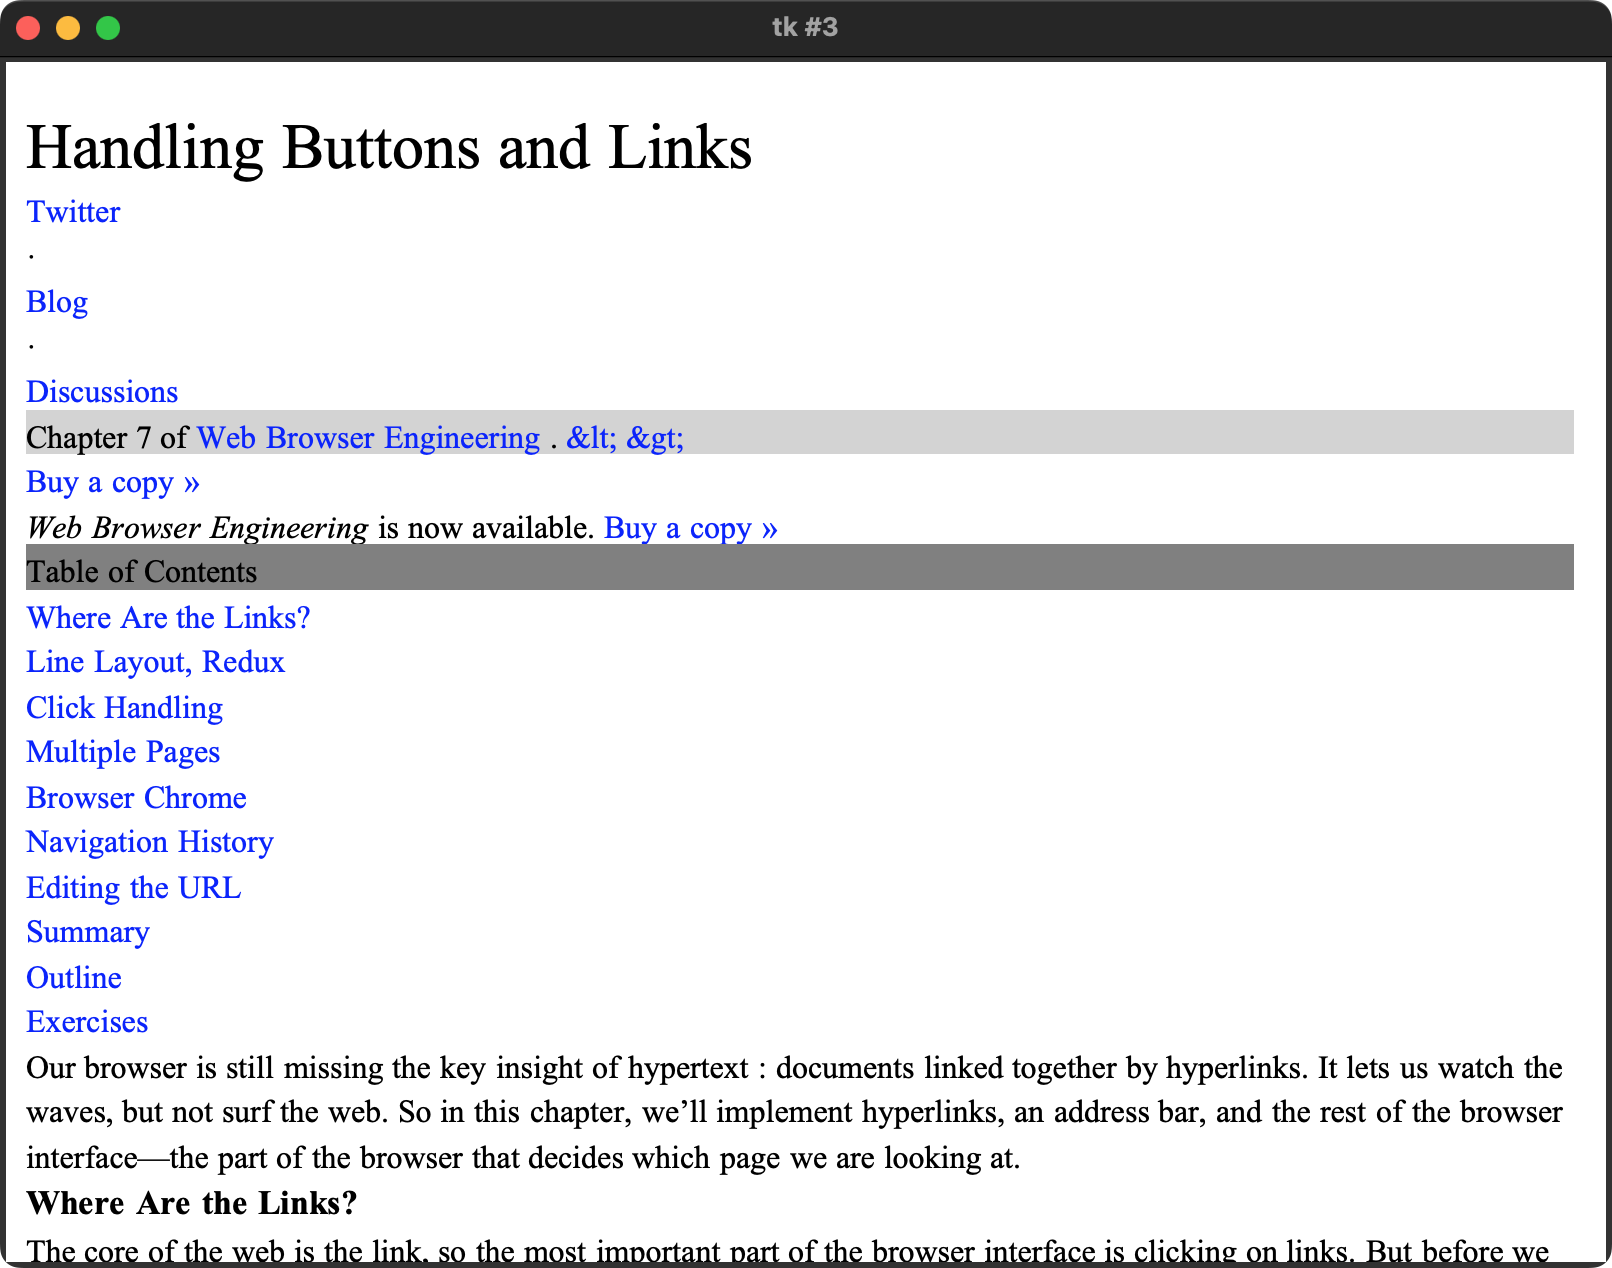

In [3]:
import time
import importlib
import browser.layout
import browser.browser

# 💡 layout.py 파일 수정을 주피터 메모리에 즉시 반영 (모듈 핫 리로드)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.url import URL
from browser.browser import Browser
from browser.layout import TextLayout, DrawRect
from browser.tk_capture import display_tk_window

# 1. 7.2 리팩터링 후 Browser 실행 및 실제 웹 페이지 로드
url = URL("https://browser.engineering/chrome.html")
browser = Browser()
browser.load(url)

# 2. Tkinter 윈도우 렌더링 동기화
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

# 3. 렌더링 결과 스크린샷 캡처 및 노트북 출력 (6장과 동일한 시각적 렌더링 검증)
display_tk_window(browser.window, settle_seconds=0.5)

# 4. 7.2의 핵심 가치 검증: 화면의 링크(<a>)들이 실제 TextLayout 객체로 크기와 좌표를 가지는지 확인
def find_links(layout_object, links=None):
    if links is None:
        links = []
    if isinstance(layout_object, TextLayout):
        node = layout_object.node
        curr = node
        while curr:
            if getattr(curr, "tag", None) == "a" and "href" in curr.attributes:
                links.append((layout_object, curr.attributes["href"]))
                break
            curr = curr.parent
    for child in layout_object.children:
        find_links(child, links)
    return links

link_objects = find_links(browser.document)
print(f"\n=== 7.2 핵심 검증: 레이아웃 트리에서 추출된 링크 단어 수: {len(link_objects)}개 ===")
for text_layout, href in link_objects[:8]:
    print(f"  단어: '{text_layout.word:<12}' | 좌표: (x={text_layout.x:>3}, y={text_layout.y:>4}, w={text_layout.width:>3}, h={text_layout.height:>2}) | URL: {href}")

## 7.3 Click Handling

In [2]:
import time
import importlib
import browser.browser
importlib.reload(browser.browser)

from browser.url import URL
from browser.browser import Browser
from browser.layout import TextLayout
from browser.tk_capture import display_tk_window

# 1. chrome.html 페이지 로드
browser = Browser()
browser.load(URL("https://browser.engineering/chrome.html"))

print("현재 페이지 URL:", browser.url)

# 2. 이전 챕터("<" 링크, href="styles.html") 단어 객체 찾기
target_text = None
def find_target_link(layout_object):
    global target_text
    if target_text:
        return
    if isinstance(layout_object, TextLayout):
        curr = layout_object.node
        while curr:
            if getattr(curr, "tag", None) == "a" and curr.attributes.get("href") == "styles.html":
                target_text = layout_object
                return
            curr = curr.parent
    for child in layout_object.children:
        find_target_link(child)

find_target_link(browser.document)

if target_text:
    print(f"클릭 대상 링크 발견! 단어: '{target_text.word}', 좌표: (x={target_text.x}, y={target_text.y})")
    
    # 3. 마우스 클릭 이벤트 모의 생성 (클릭 좌표: 단어의 중심)
    class MockClickEvent:
        def __init__(self, x, y):
            self.x = x
            self.y = y
            
    click_x = target_text.x + target_text.width // 2
    click_y = target_text.y + target_text.height // 2
    
    print(f"\n👉 ({click_x}, {click_y}) 좌표 클릭 시뮬레이션 실행...")
    browser.click(MockClickEvent(click_x, click_y))
    
    # 4. 클릭 후 페이지 이동 확인
    for _ in range(10):
        browser.window.update_idletasks()
        browser.window.update()
        time.sleep(0.05)
        
    print("\n새로 이동된 페이지 URL:", browser.url)
    # display_tk_window(browser.window, settle_seconds=0.5)
else:
    print("클릭 대상 링크를 찾지 못했습니다.")


현재 페이지 URL: <browser.url.URL object at 0x1139997b0>
클릭 대상 링크 발견! 단어: '&lt;', 좌표: (x=283, y=180.5)

👉 (296, 189.5) 좌표 클릭 시뮬레이션 실행...

새로 이동된 페이지 URL: <browser.url.URL object at 0x1139a3a50>


## 7.4 Multiple Pages

1. 첫 번째 탭 생성 완료! 전체 탭 수: 1, 활성 탭: <browser.url.URL object at 0x10de28830>
2. 두 번째 탭 생성 완료! 전체 탭 수: 2, 활성 탭: <browser.url.URL object at 0x10de35480>
3. 첫 번째 탭으로 활성 탭 복귀: <browser.url.URL object at 0x10de28830>


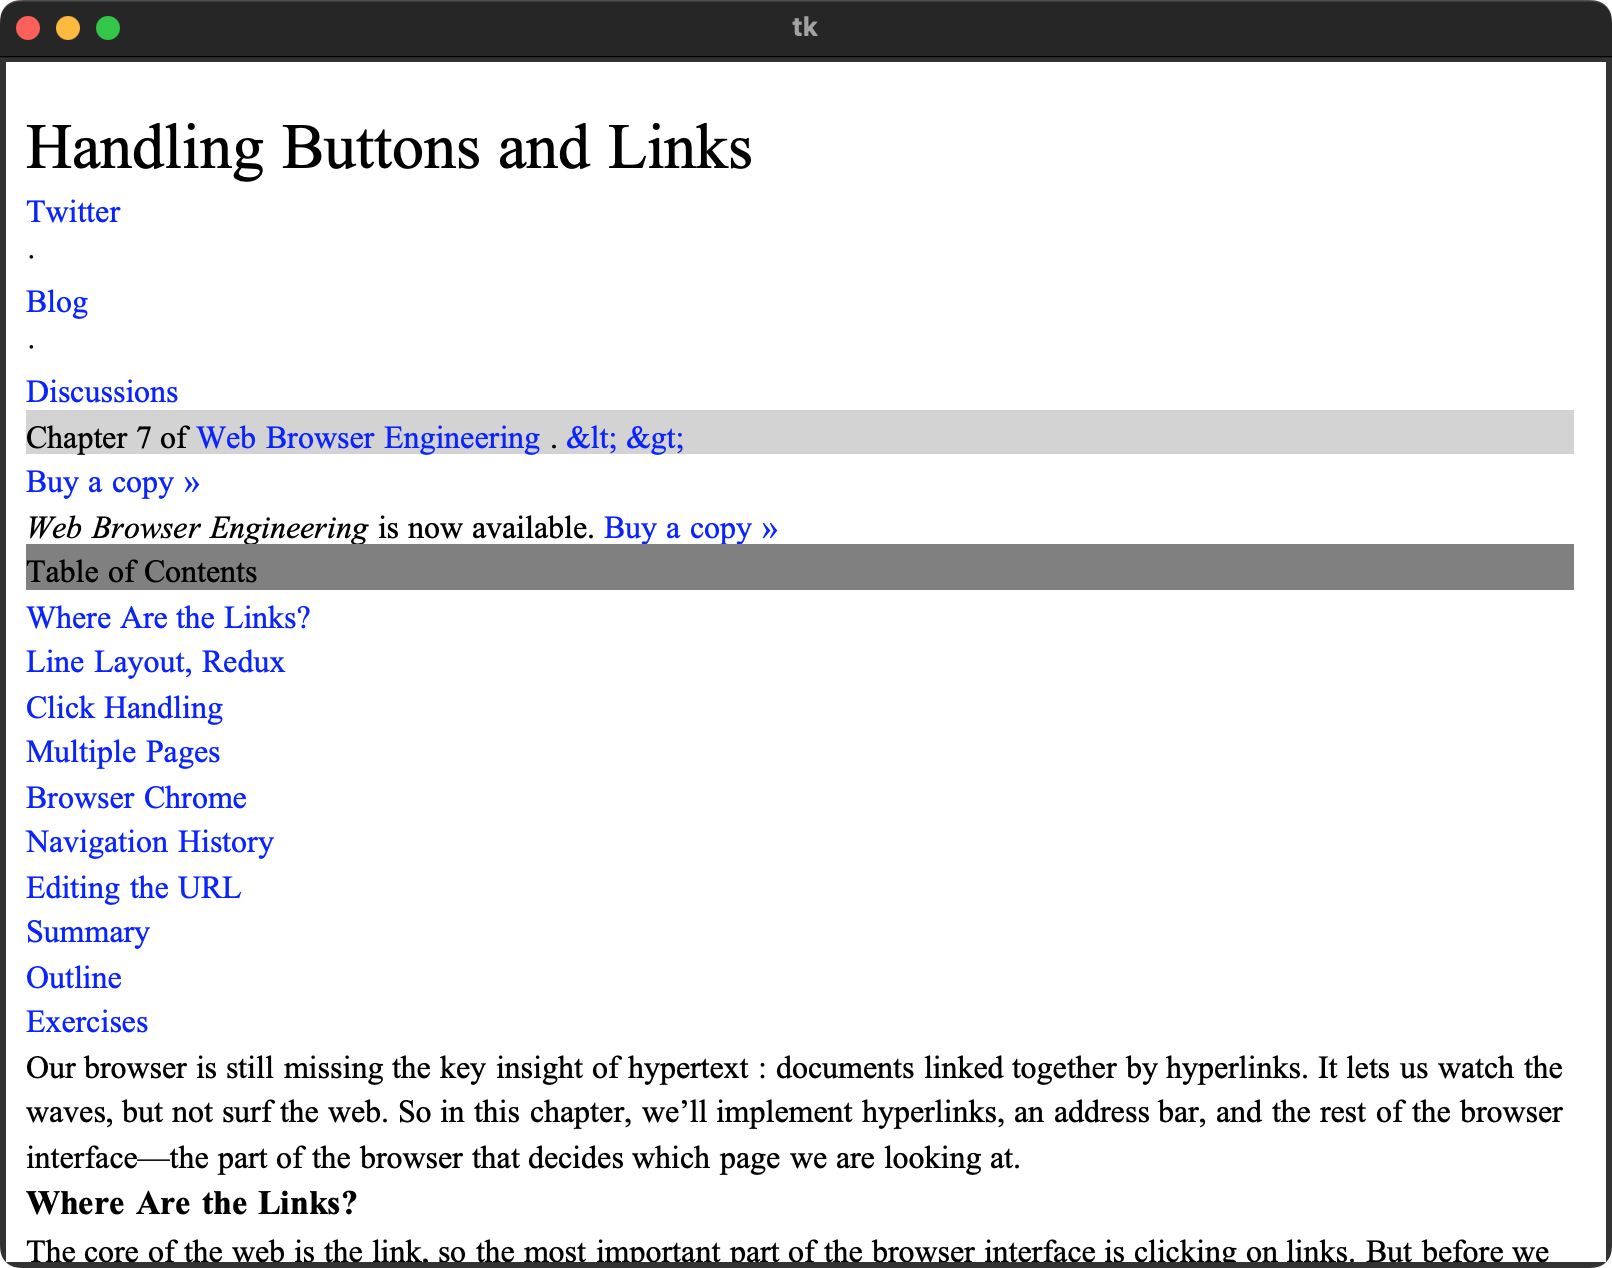

In [5]:
import importlib
import browser.browser
importlib.reload(browser.browser)

from browser.browser import Browser, Tab
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 인스턴스 생성
browser = Browser()

# 2. 첫 번째 탭 생성 (chrome.html - Chapter 7)
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 첫 번째 탭 생성 완료! 전체 탭 수: {len(browser.tabs)}, 활성 탭: {browser.active_tab.url}")

# 3. 두 번째 탭 생성 (styles.html - Chapter 6)
browser.new_tab(URL("https://browser.engineering/styles.html"))
print(f"2. 두 번째 탭 생성 완료! 전체 탭 수: {len(browser.tabs)}, 활성 탭: {browser.active_tab.url}")

# 4. 첫 번째 탭으로 다시 활성화 전환
browser.active_tab = browser.tabs[0]
browser.draw()
print(f"3. 첫 번째 탭으로 활성 탭 복귀: {browser.active_tab.url}")

# 첫 번째 탭으로 돌아온 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.5 Browser Chrome


1. 첫 탭 오픈: 1개 탭, 활성: <browser.url.URL object at 0x11193d7f0>
2. 상단 '+' 버튼 클릭 (x=10, y=10)...
   -> 새 탭 생성 완료! 전체 탭 수: 2, 현재 활성 탭: <browser.url.URL object at 0x11197cb00>
3. 상단 'Tab 0' 클릭 (x=41, y=5)...
   -> 활성 탭 전환 완료! 현재 활성 탭: <browser.url.URL object at 0x11193d7f0>


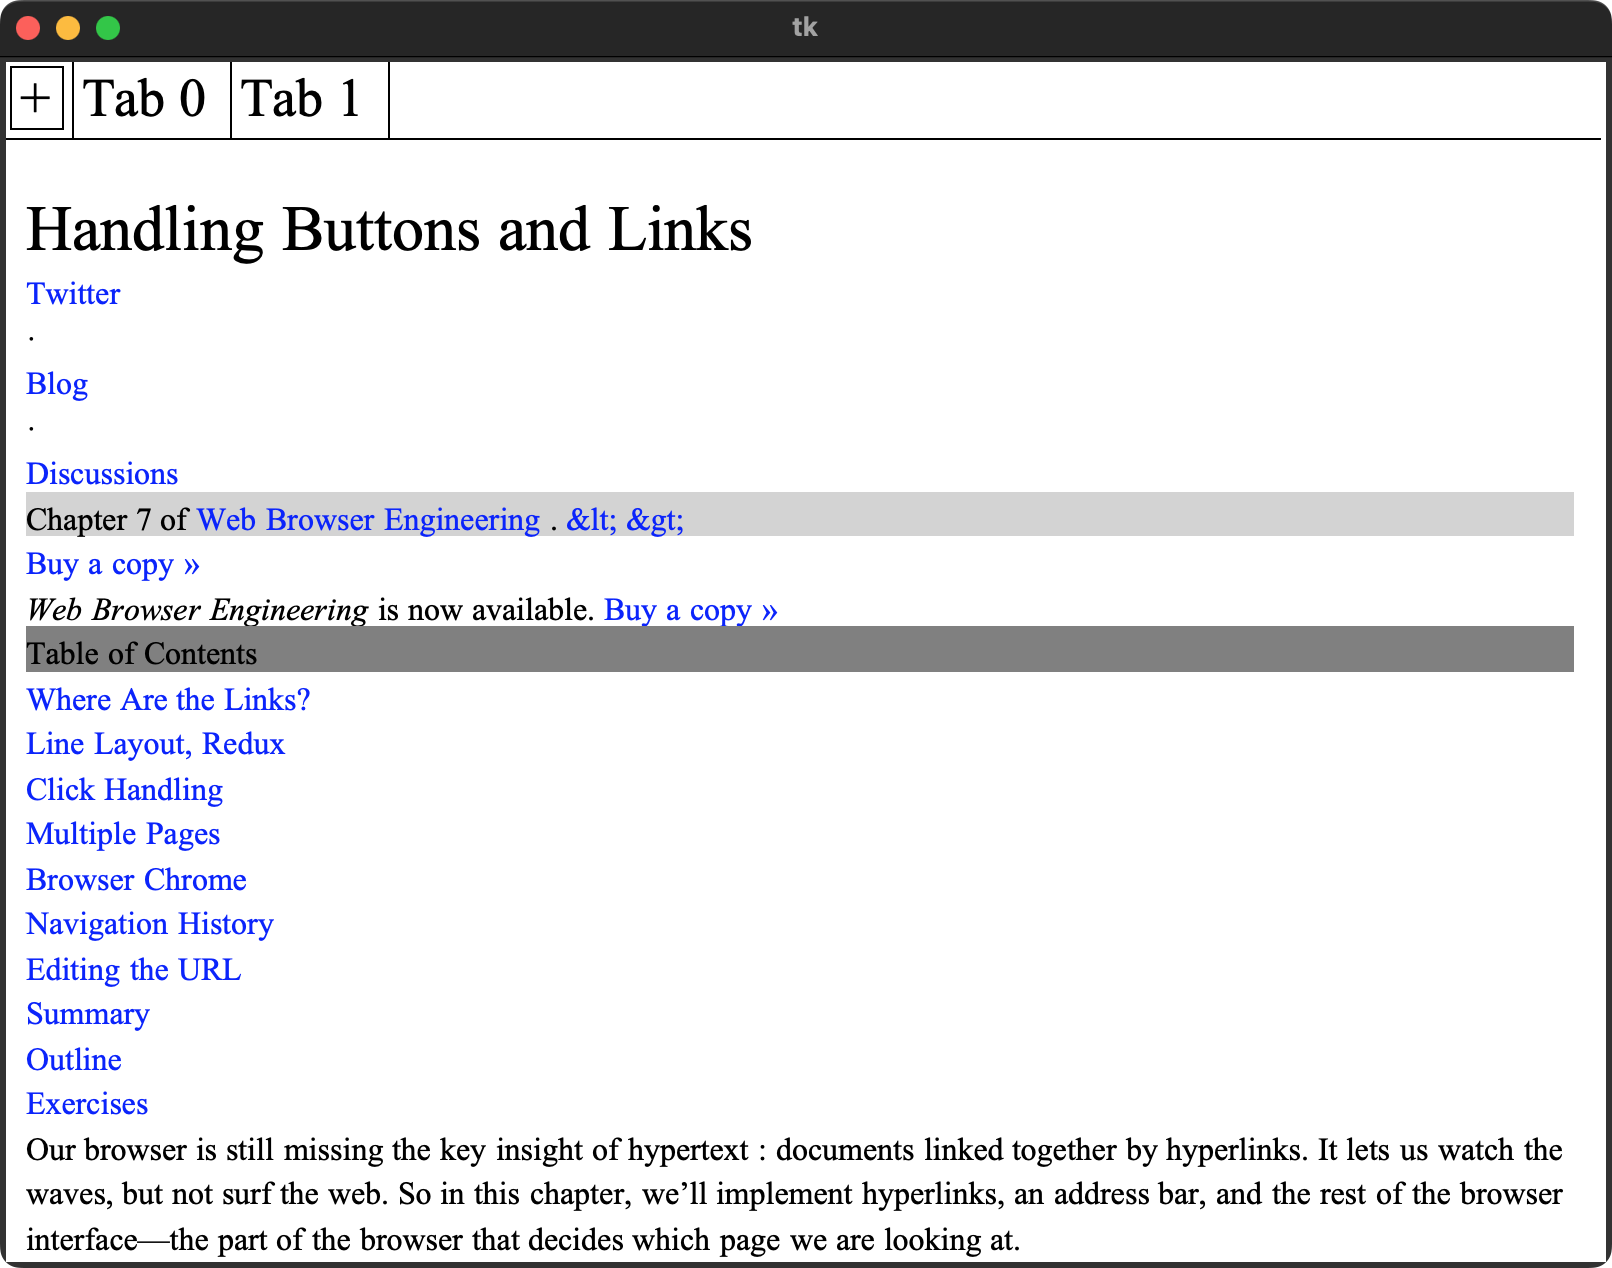

In [1]:
import importlib
import browser.browser
import browser.layout
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 첫 탭 로드 (chrome.html)
browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 첫 탭 오픈: {len(browser.tabs)}개 탭, 활성: {browser.active_tab.url}")

# 2. 상단 '+' 버튼 클릭 시뮬레이션 (새 탭 열기)
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

plus_x = browser.chrome.newtab_rect.left + 5
plus_y = browser.chrome.newtab_rect.top + 5
print(f"2. 상단 '+' 버튼 클릭 (x={plus_x}, y={plus_y})...")
browser.handle_click(MockClick(plus_x, plus_y))
print(f"   -> 새 탭 생성 완료! 전체 탭 수: {len(browser.tabs)}, 현재 활성 탭: {browser.active_tab.url}")

# 3. 상단 'Tab 0' 영역 클릭 시뮬레이션 (탭 0으로 다시 전환)
tab0_rect = browser.chrome.tab_rect(0)
tab0_x = tab0_rect.left + 5
tab0_y = tab0_rect.top + 5
print(f"3. 상단 'Tab 0' 클릭 (x={tab0_x}, y={tab0_y})...")
browser.handle_click(MockClick(tab0_x, tab0_y))
print(f"   -> 활성 탭 전환 완료! 현재 활성 탭: {browser.active_tab.url}")

browser.draw()
# 4. 상단에 탭 바('+' 버튼, 'Tab 0', 'Tab 1')가 선명하게 그려진 브라우저 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.6 Navigation History


1. 첫 페이지 로드: https://browser.engineering/chrome.html
   방문 기록: ['https://browser.engineering/chrome.html']
2. 두 번째 페이지로 이동: https://browser.engineering/http.html
   방문 기록: ['https://browser.engineering/chrome.html', 'https://browser.engineering/http.html']
3. 크롬 '<' 뒤로가기 버튼 클릭 (x=10, y=51)...
   -> 이전 페이지로 복귀 완료! 현재 URL: https://browser.engineering/chrome.html
   현재 방문 기록: ['https://browser.engineering/chrome.html']


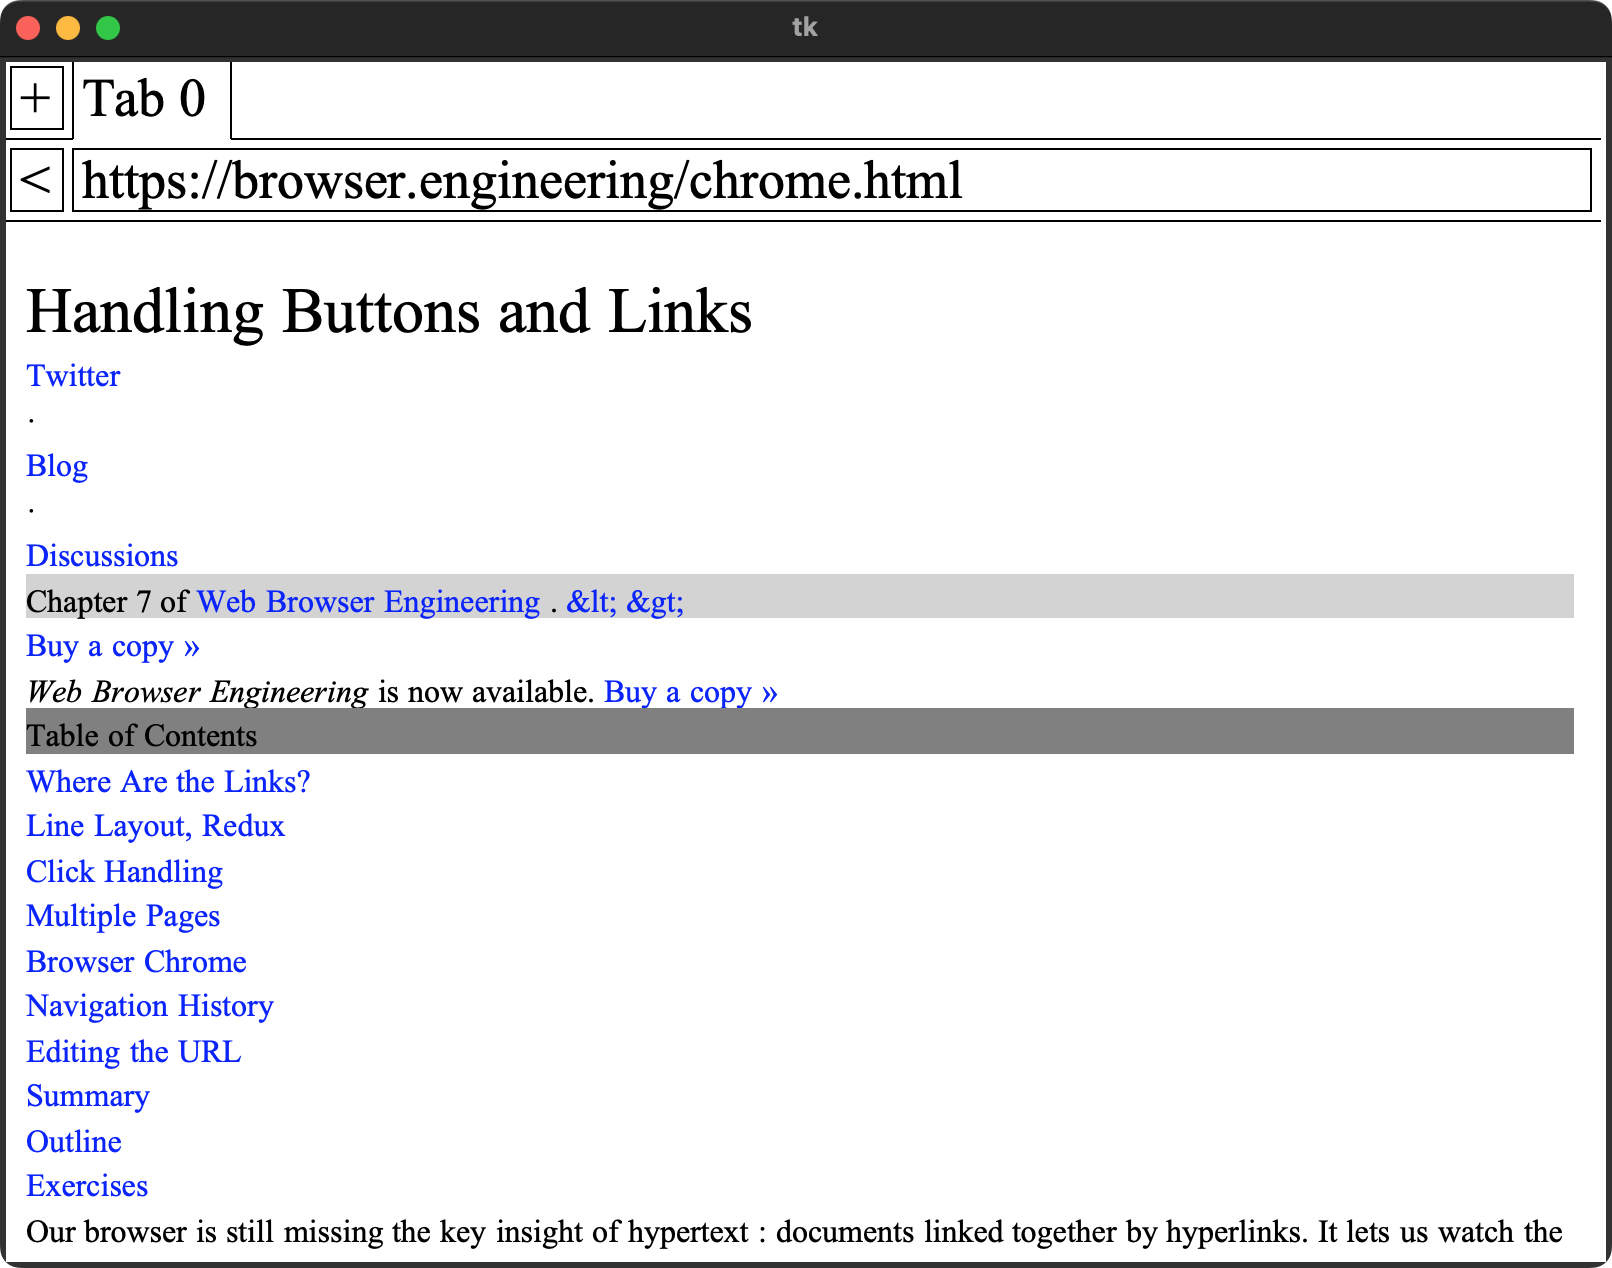

In [1]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 첫 페이지 로드
browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 첫 페이지 로드: {browser.active_tab.url}")
print(f"   방문 기록: {[str(u) for u in browser.active_tab.history]}")

# 2. 두 번째 페이지(http.html)로 이동하여 방문 기록 쌓기
browser.active_tab.load(URL("https://browser.engineering/http.html"))
print(f"2. 두 번째 페이지로 이동: {browser.active_tab.url}")
print(f"   방문 기록: {[str(u) for u in browser.active_tab.history]}")

# 3. 크롬 '<' 뒤로가기 버튼 클릭 시뮬레이션
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

back_x = browser.chrome.back_rect.left + 5
back_y = browser.chrome.back_rect.top + 5
print(f"3. 크롬 '<' 뒤로가기 버튼 클릭 (x={back_x}, y={back_y})...")
browser.handle_click(MockClick(back_x, back_y))

print(f"   -> 이전 페이지로 복귀 완료! 현재 URL: {browser.active_tab.url}")
print(f"   현재 방문 기록: {[str(u) for u in browser.active_tab.history]}")

browser.draw()
# 4. 상단 2줄 크롬(탭 바 + 뒤로가기 버튼과 URL 주소창)이 완벽히 렌더링된 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.7 Editing the URL


1. 초기 페이지 로드: https://browser.engineering/chrome.html
2. 주소창 클릭 (x=46, y=56)...
   포커스 상태: address bar, 주소창 버퍼: ''
3. 키보드로 'https://browser.engineering/layout.html' 입력 시뮬레이션...
   입력 완료 후 주소창 버퍼: 'https://browser.engineering/layout.html'
4. Enter 키 입력 -> 새 페이지로 이동 실행...
   -> 이동 완료! 현재 탭 URL: https://browser.engineering/layout.html
   포커스 해제 상태: None
   방문 기록(History): ['https://browser.engineering/chrome.html', 'https://browser.engineering/layout.html']


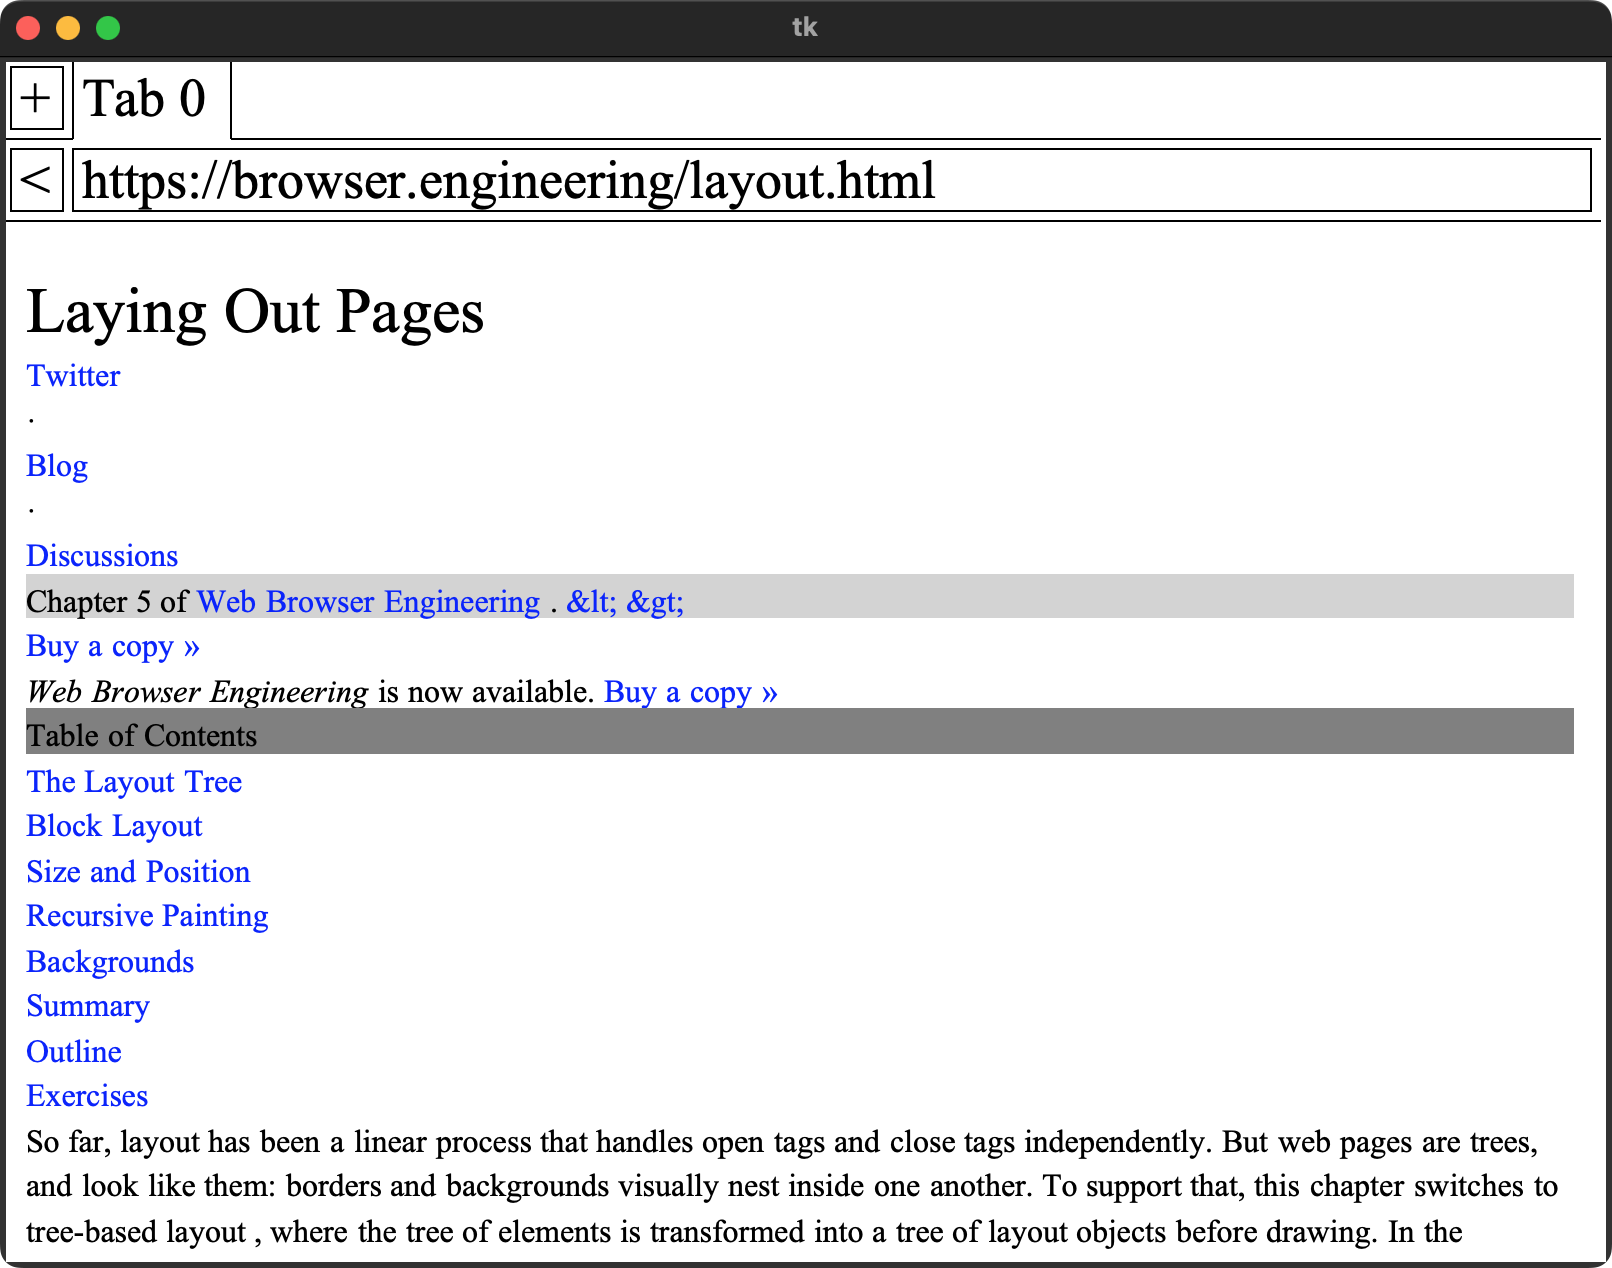

In [1]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 초기 페이지 로드
browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 초기 페이지 로드: {browser.active_tab.url}")

# 2. 주소창 클릭 시뮬레이션 (포커스 획득 및 주소창 비우기)
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

addr_x = browser.chrome.address_rect.left + 10
addr_y = browser.chrome.address_rect.top + 10
print(f"2. 주소창 클릭 (x={addr_x}, y={addr_y})...")
browser.handle_click(MockClick(addr_x, addr_y))
print(f"   포커스 상태: {browser.chrome.focus}, 주소창 버퍼: '{browser.chrome.address_bar}'")

# 3. 키보드로 새 URL 타이핑 시뮬레이션
class MockKeyEvent:
    def __init__(self, char):
        self.char = char

target_url = "https://browser.engineering/layout.html"
print(f"3. 키보드로 '{target_url}' 입력 시뮬레이션...")
for ch in target_url:
    browser.handle_key(MockKeyEvent(ch))

print(f"   입력 완료 후 주소창 버퍼: '{browser.chrome.address_bar}'")

# 4. 엔터(Return) 키 입력 시뮬레이션 (페이지 이동)
print("4. Enter 키 입력 -> 새 페이지로 이동 실행...")
browser.handle_enter(None)
print(f"   -> 이동 완료! 현재 탭 URL: {browser.active_tab.url}")
print(f"   포커스 해제 상태: {browser.chrome.focus}")
print(f"   방문 기록(History): {[str(u) for u in browser.active_tab.history]}")

browser.draw()
# 5. 주소창 입력을 통해 새로 이동한 페이지(layout.html) 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.10 Exercises: 7-1 Backspace

Add support for the backspace key when typing in the address bar. Honestly, do this exercise just for your sanity.

1. 초기 페이지 로드: https://browser.engineering/http.html
2. 주소창 클릭 -> 포커스: address bar, 버퍼: ''
3. 오타가 포함된 URL 입력: 'https://browser.engineering/chrome.htmlXXX'
   현재 주소창 버퍼: 'https://browser.engineering/chrome.htmlXXX'
4. 백스페이스(Backspace) 키 3회 입력 시뮬레이션...
   백스페이스 후 주소창 버퍼: 'https://browser.engineering/chrome.html'
5. Enter 키 입력 -> 수정된 URL로 이동...
   -> 이동 완료! 현재 탭 URL: https://browser.engineering/chrome.html


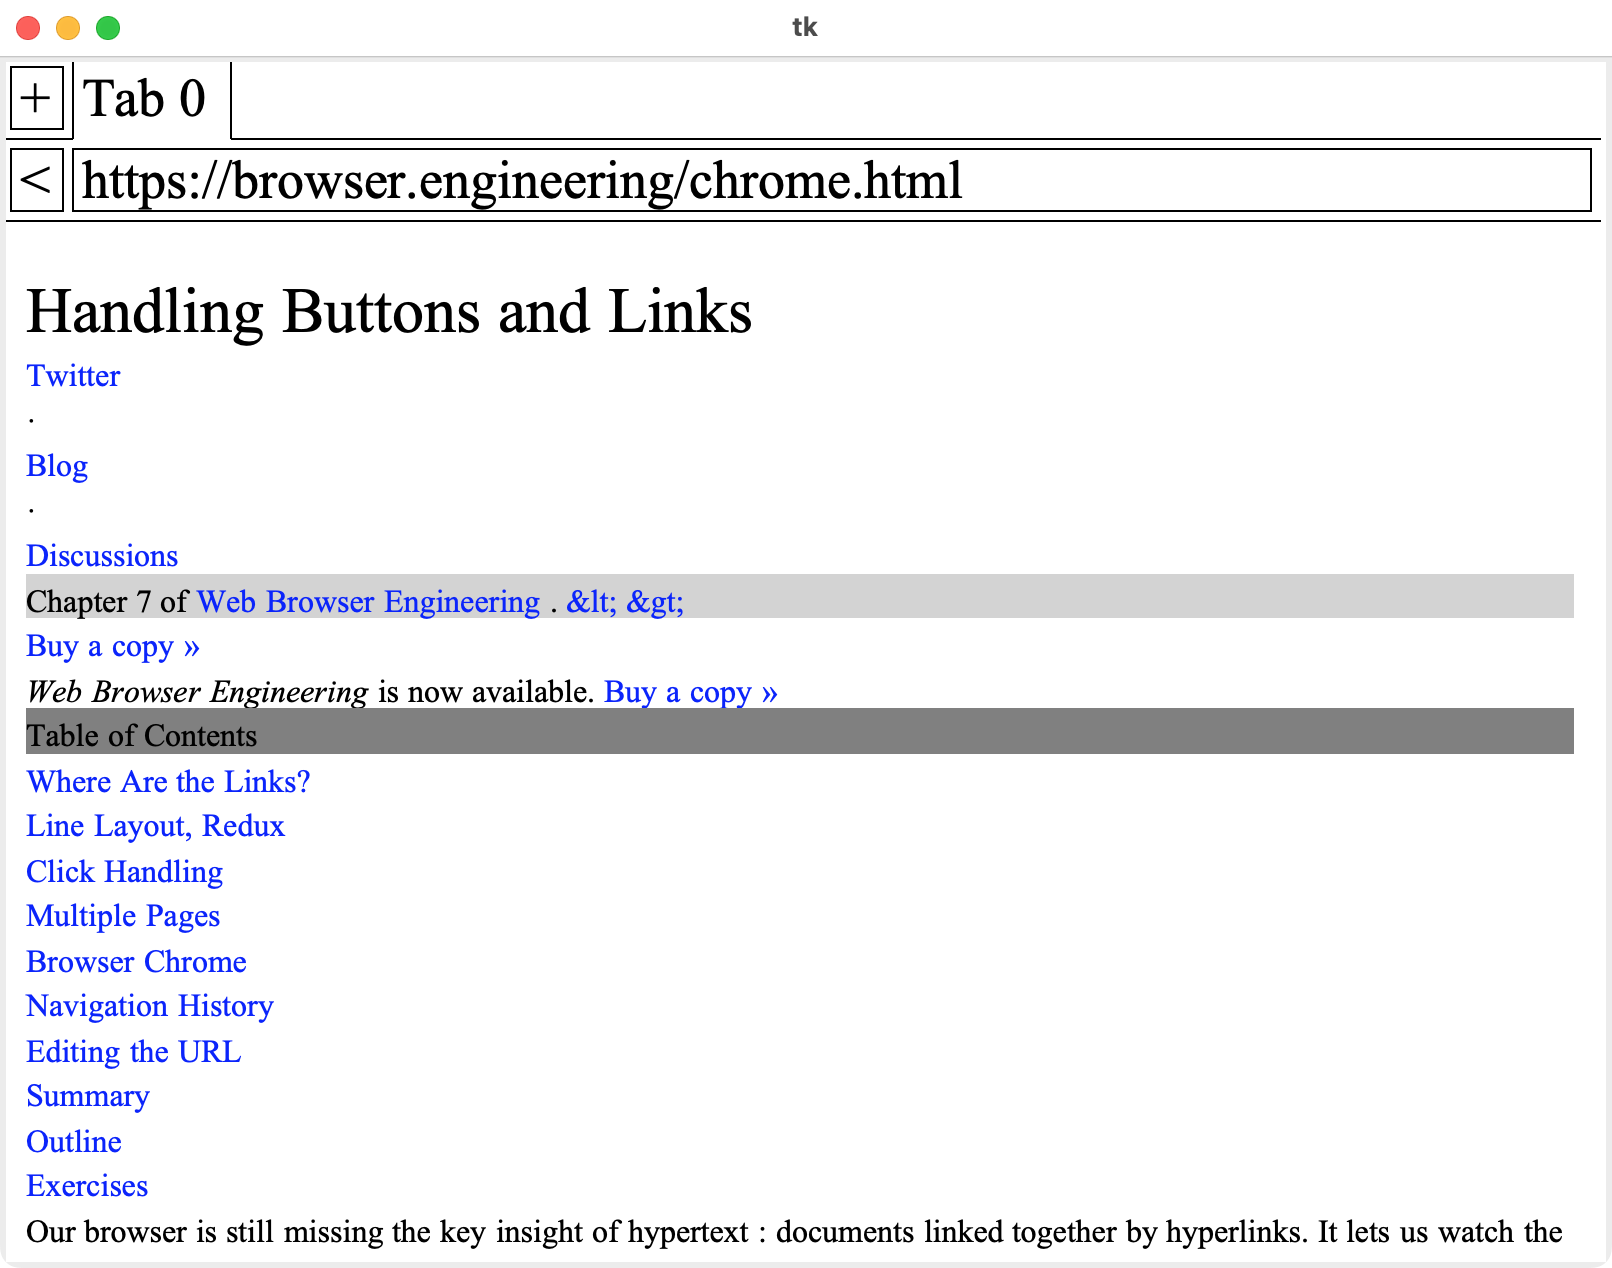

In [1]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 초기 페이지 로드
browser = Browser()
browser.new_tab(URL("https://browser.engineering/http.html"))
print(f"1. 초기 페이지 로드: {browser.active_tab.url}")

# 2. 주소창 클릭 (포커스 획득 및 주소창 비우기)
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

addr_x = browser.chrome.address_rect.left + 10
addr_y = browser.chrome.address_rect.top + 10
browser.handle_click(MockClick(addr_x, addr_y))
print(f"2. 주소창 클릭 -> 포커스: {browser.chrome.focus}, 버퍼: '{browser.chrome.address_bar}'")

# 3. 키보드로 오타가 포함된 URL 타이핑 시뮬레이션
class MockKeyEvent:
    def __init__(self, char):
        self.char = char

typo_url = "https://browser.engineering/chrome.htmlXXX"
print(f"3. 오타가 포함된 URL 입력: '{typo_url}'")
for ch in typo_url:
    browser.handle_key(MockKeyEvent(ch))
print(f"   현재 주소창 버퍼: '{browser.chrome.address_bar}'")

# 4. 백스페이스 키 3회 입력 시뮬레이션 (XXX 삭제)
print("4. 백스페이스(Backspace) 키 3회 입력 시뮬레이션...")
for _ in range(3):
    browser.handle_backspace(None)
print(f"   백스페이스 후 주소창 버퍼: '{browser.chrome.address_bar}'")

# 5. 엔터(Return) 키 입력으로 해당 페이지로 이동
print("5. Enter 키 입력 -> 수정된 URL로 이동...")
browser.handle_enter(None)
print(f"   -> 이동 완료! 현재 탭 URL: {browser.active_tab.url}")

browser.draw()
# 6. 백스페이스로 올바르게 수정한 후 로드된 chrome.html 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.10 Exercises: 7-4 Forward

Add a forward button, which should undo the back button. If the most recent navigation action wasn’t a back button, the forward button shouldn’t do anything.To accomplish this, you’ll need to keep around history items when clicking the back button, and store an index into it for the current page, instead of removing them entirely from the array. Draw it in gray in that case, so the user isn’t stuck wondering why it doesn’t work. Also draw the back button in gray if there’s nowhere to go back to.

### Step 1: 초기 페이지 로드 (`http.html`)

브라우저 창을 생성하고 첫 번째 페이지를 로드합니다.
- 아직 이전 페이지나 다음 페이지가 없으므로 뒤로가기(`<`)와 앞으로가기(`>`) 버튼이 모두 **회색(gray, 비활성화)**으로 렌더링됩니다.

현재 URL: https://browser.engineering/http.html
방문 기록: ['https://browser.engineering/http.html']
히스토리 포인터: 0
뒤로가기 가능: False (색상: gray)
앞으로가기 가능: False (색상: gray)


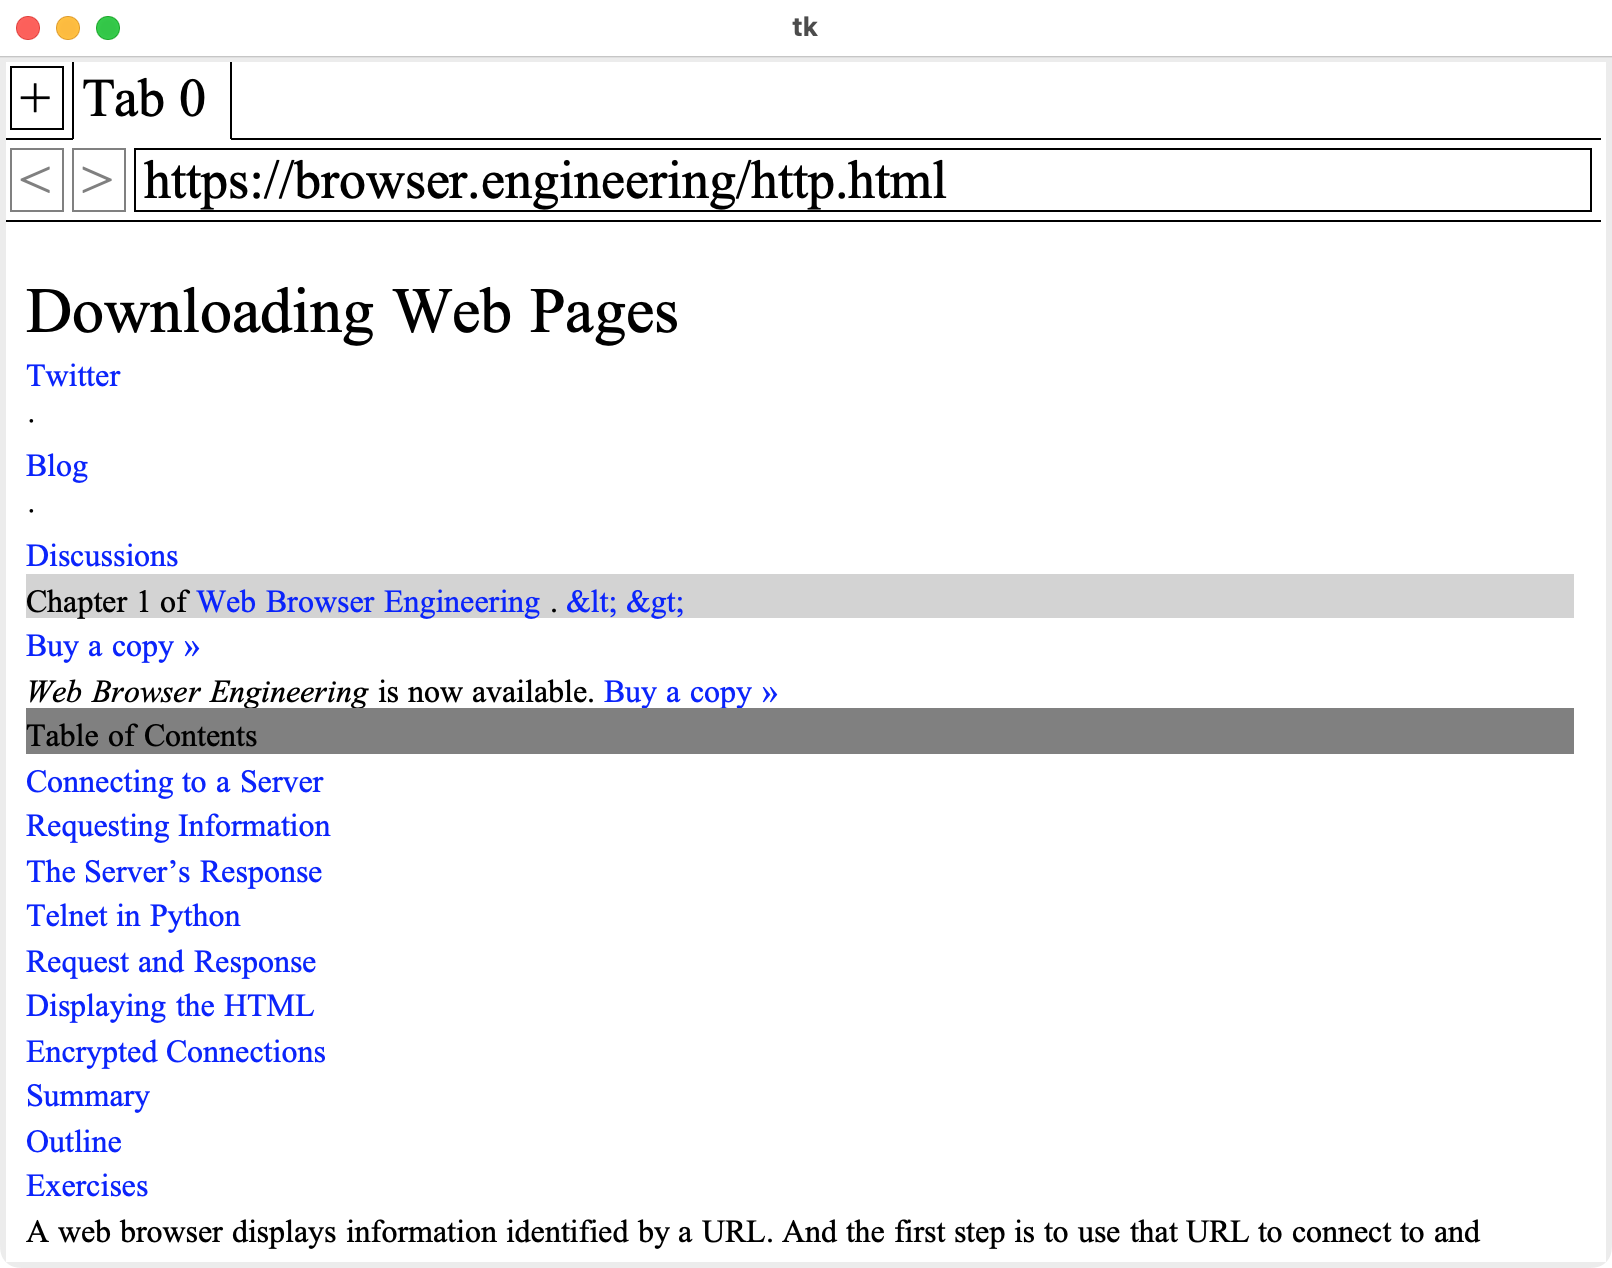

In [ ]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

browser = Browser()
browser.new_tab(URL("https://browser.engineering/http.html"))

tab = browser.active_tab
print(f"현재 URL: {tab.url}")
print(f"방문 기록: {[str(u) for u in tab.history]}")
print(f"히스토리 포인터: {tab.history_pointer}")
print(f"뒤로가기 가능: {tab.history_pointer > 0} (색상: {'black' if tab.history_pointer > 0 else 'gray'})")
print(f"앞으로가기 가능: {tab.history_pointer < len(tab.history) - 1} (색상: {'black' if tab.history_pointer < len(tab.history) - 1 else 'gray'})")

browser.draw()
display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 2: 두 번째 페이지로 이동 (`chrome.html`)

새로운 URL을 로드합니다.
- 이제 이전 페이지(`http.html`)가 존재하므로 뒤로가기(`<`) 버튼이 **검은색(black, 활성화)**으로 켜집니다.
- 앞으로 갈 페이지는 아직 없으므로 앞으로가기(`>`) 버튼은 여전히 **회색(gray, 비활성화)**입니다.

현재 URL: https://browser.engineering/chrome.html
방문 기록: ['https://browser.engineering/http.html', 'https://browser.engineering/chrome.html']
히스토리 포인터: 1
뒤로가기 가능: True (색상: black)
앞으로가기 가능: False (색상: gray)


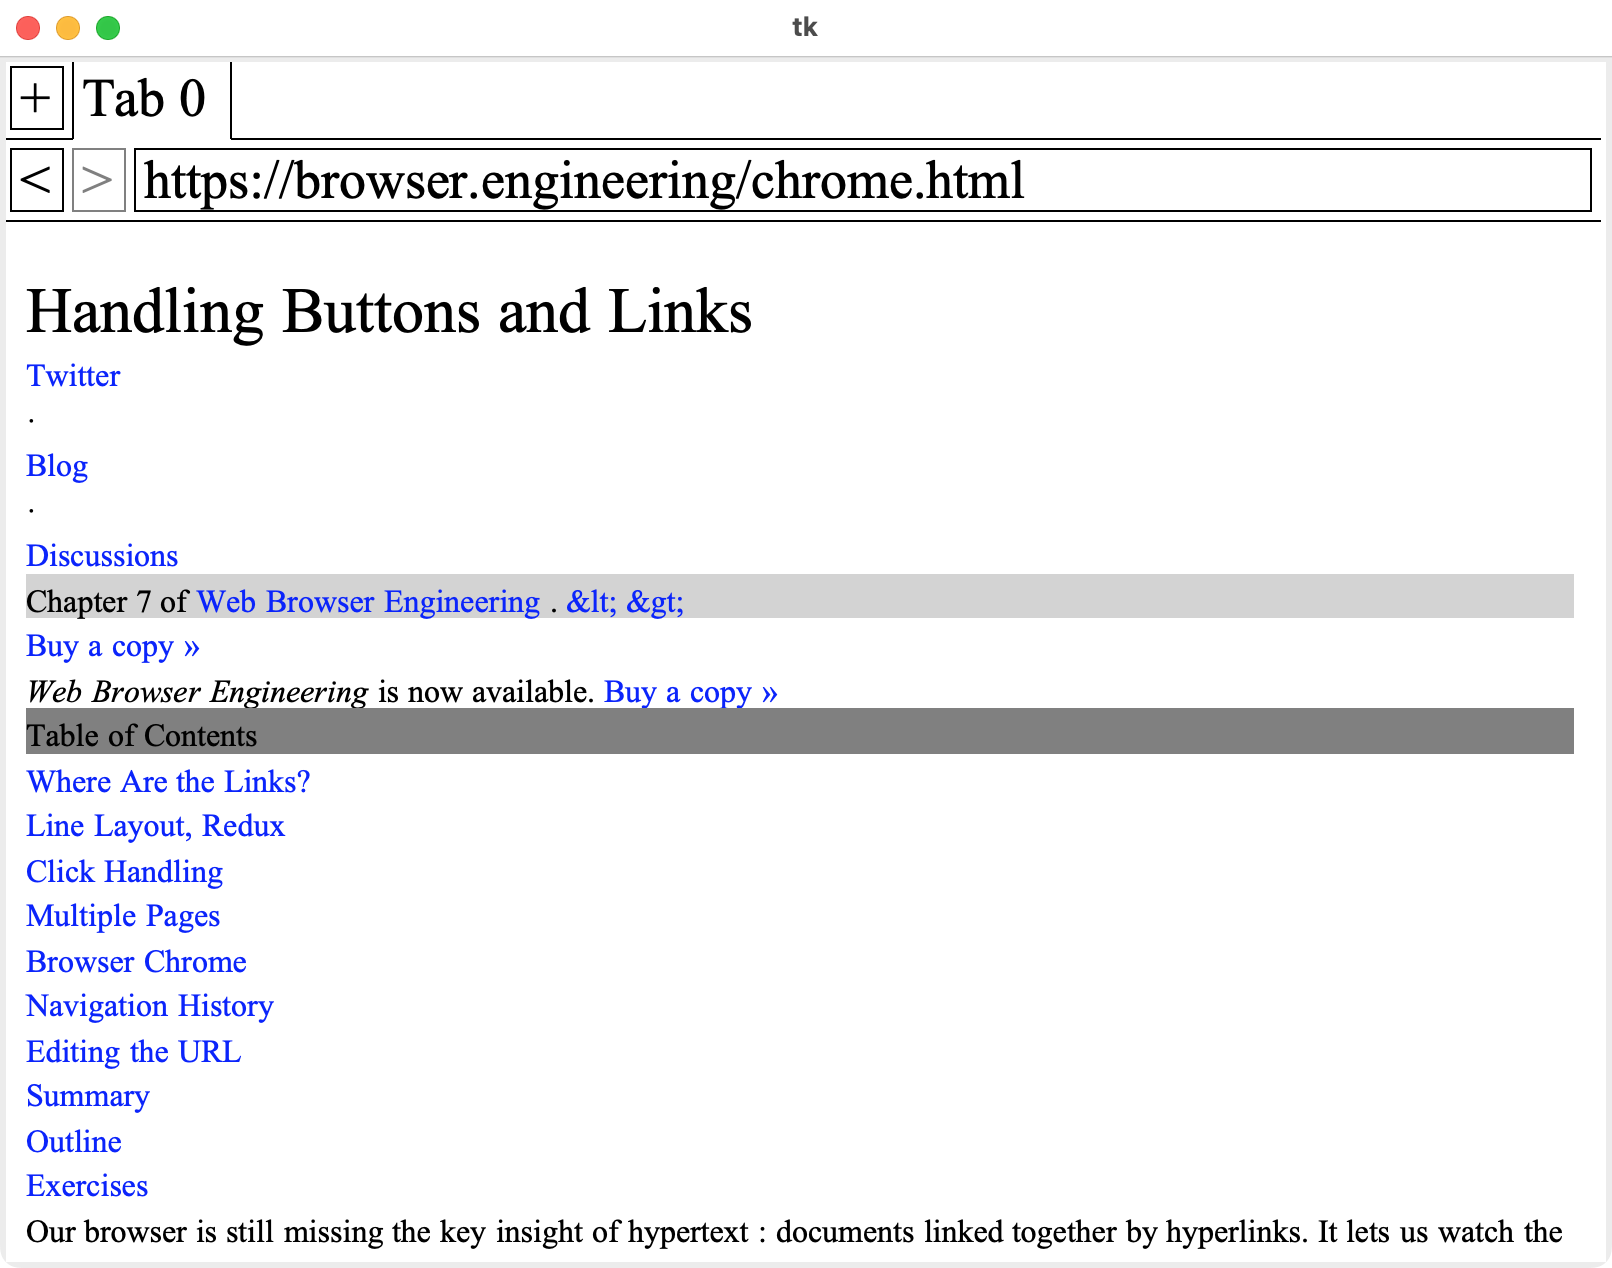

In [ ]:
# 두 번째 페이지로 이동
browser.active_tab.load(URL("https://browser.engineering/chrome.html"))
browser.draw()

tab = browser.active_tab
print(f"현재 URL: {tab.url}")
print(f"방문 기록: {[str(u) for u in tab.history]}")
print(f"히스토리 포인터: {tab.history_pointer}")
print(f"뒤로가기 가능: {tab.history_pointer > 0} (색상: {'black' if tab.history_pointer > 0 else 'gray'})")
print(f"앞으로가기 가능: {tab.history_pointer < len(tab.history) - 1} (색상: {'black' if tab.history_pointer < len(tab.history) - 1 else 'gray'})")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 3: 뒤로가기(`<`) 버튼 클릭

뒤로가기 버튼(`<`)을 클릭합니다.
- 첫 번째 페이지(`http.html`)로 복귀합니다.
- 더 이상 이전 페이지가 없으므로 뒤로가기(`<`)는 **회색(gray, 비활성화)**으로 꺼집니다.
- 방금 방문했던 미래 페이지(`chrome.html`)가 있으므로 앞으로가기(`>`) 버튼이 **검은색(black, 활성화)**으로 켜집니다! ✨

현재 URL: https://browser.engineering/http.html
방문 기록: ['https://browser.engineering/http.html', 'https://browser.engineering/chrome.html']
히스토리 포인터: 0
뒤로가기 가능: False (색상: gray)
앞으로가기 가능: True (색상: black)


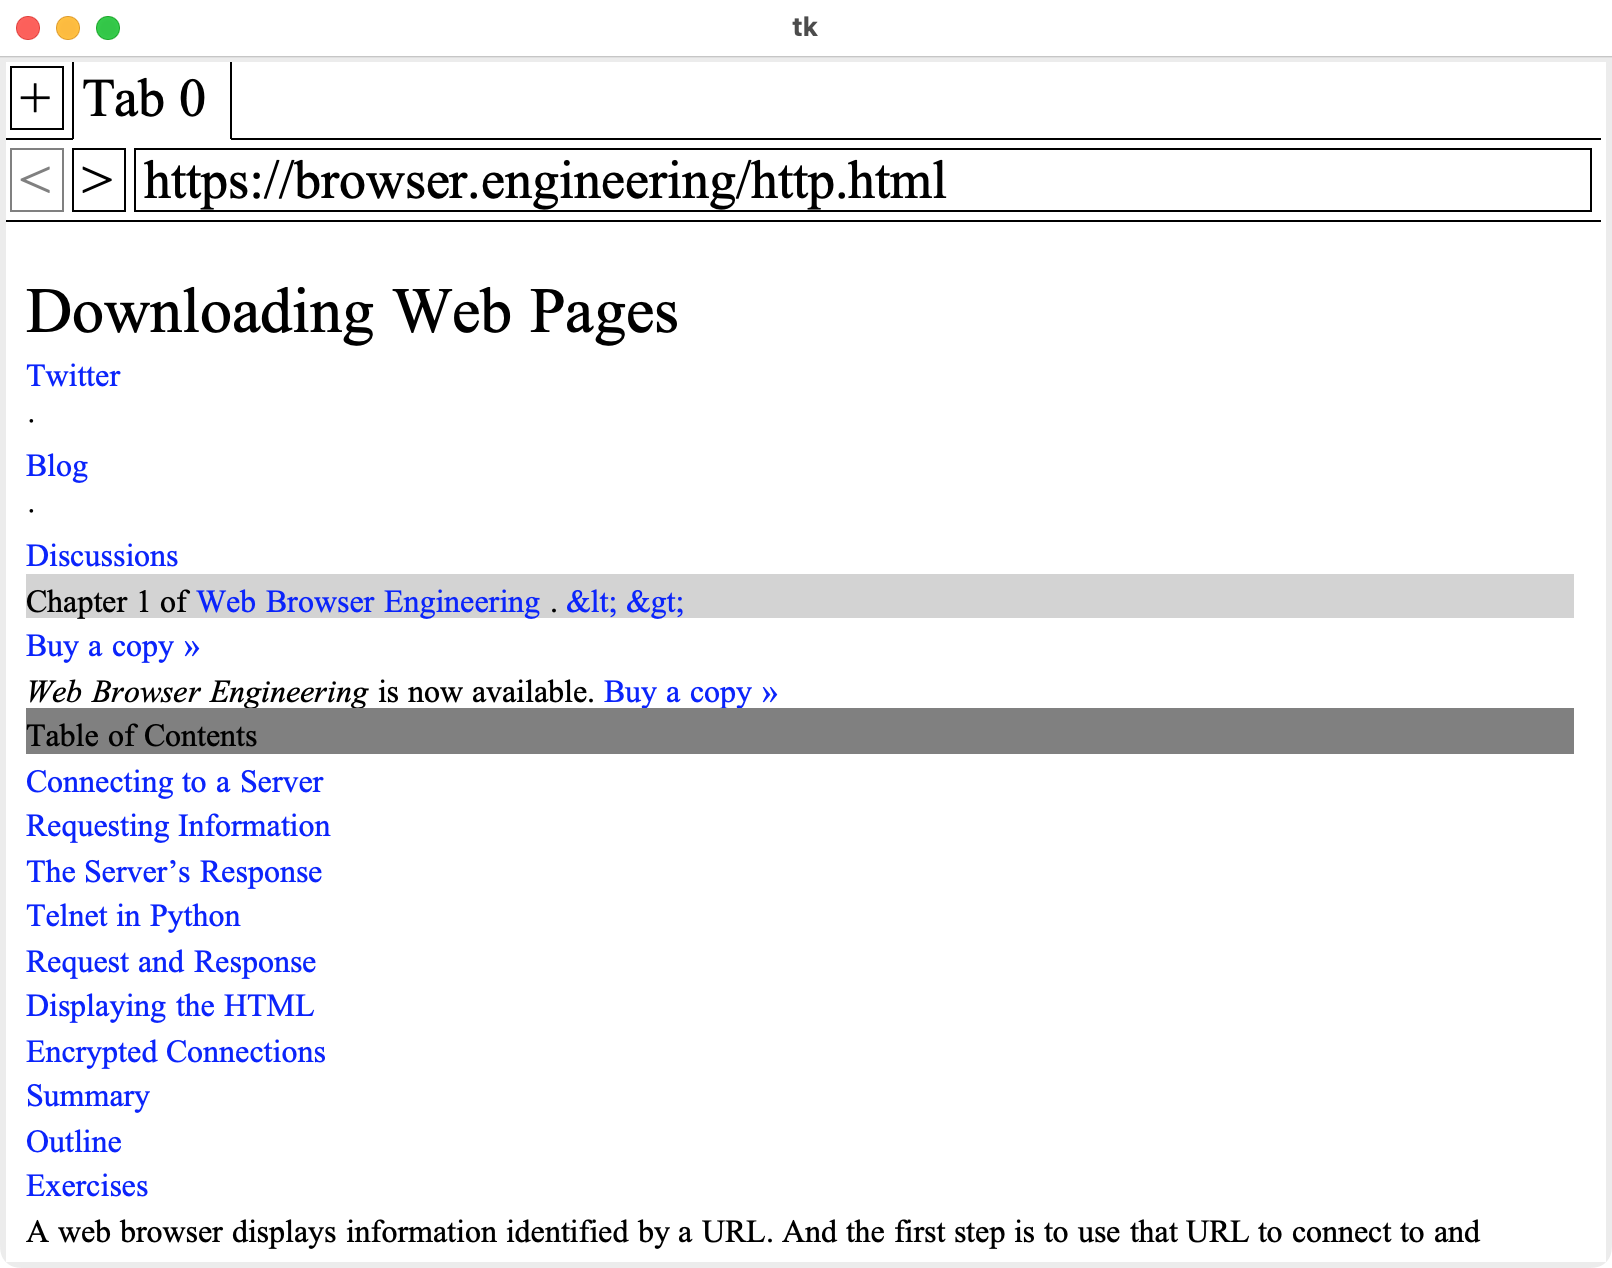

In [ ]:
# 뒤로가기 (<) 버튼 클릭 시뮬레이션
back_x = browser.chrome.back_rect.left + 5
back_y = browser.chrome.back_rect.top + 5
browser.handle_click(MockClick(back_x, back_y))

tab = browser.active_tab
print(f"현재 URL: {tab.url}")
print(f"방문 기록: {[str(u) for u in tab.history]}")
print(f"히스토리 포인터: {tab.history_pointer}")
print(f"뒤로가기 가능: {tab.history_pointer > 0} (색상: {'black' if tab.history_pointer > 0 else 'gray'})")
print(f"앞으로가기 가능: {tab.history_pointer < len(tab.history) - 1} (색상: {'black' if tab.history_pointer < len(tab.history) - 1 else 'gray'})")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 4: 앞으로가기(`>`) 버튼 클릭

활성화된 앞으로가기 버튼(`>`)을 클릭합니다.
- 다시 두 번째 페이지(`chrome.html`)로 이동합니다.
- 뒤로가기(`<`) 버튼은 다시 **검은색(black, 활성화)**이 되고, 앞으로가기(`>`)는 **회색(gray, 비활성화)**으로 돌아옵니다.

현재 URL: https://browser.engineering/chrome.html
방문 기록: ['https://browser.engineering/http.html', 'https://browser.engineering/chrome.html']
히스토리 포인터: 1
뒤로가기 가능: True (색상: black)
앞으로가기 가능: False (색상: gray)


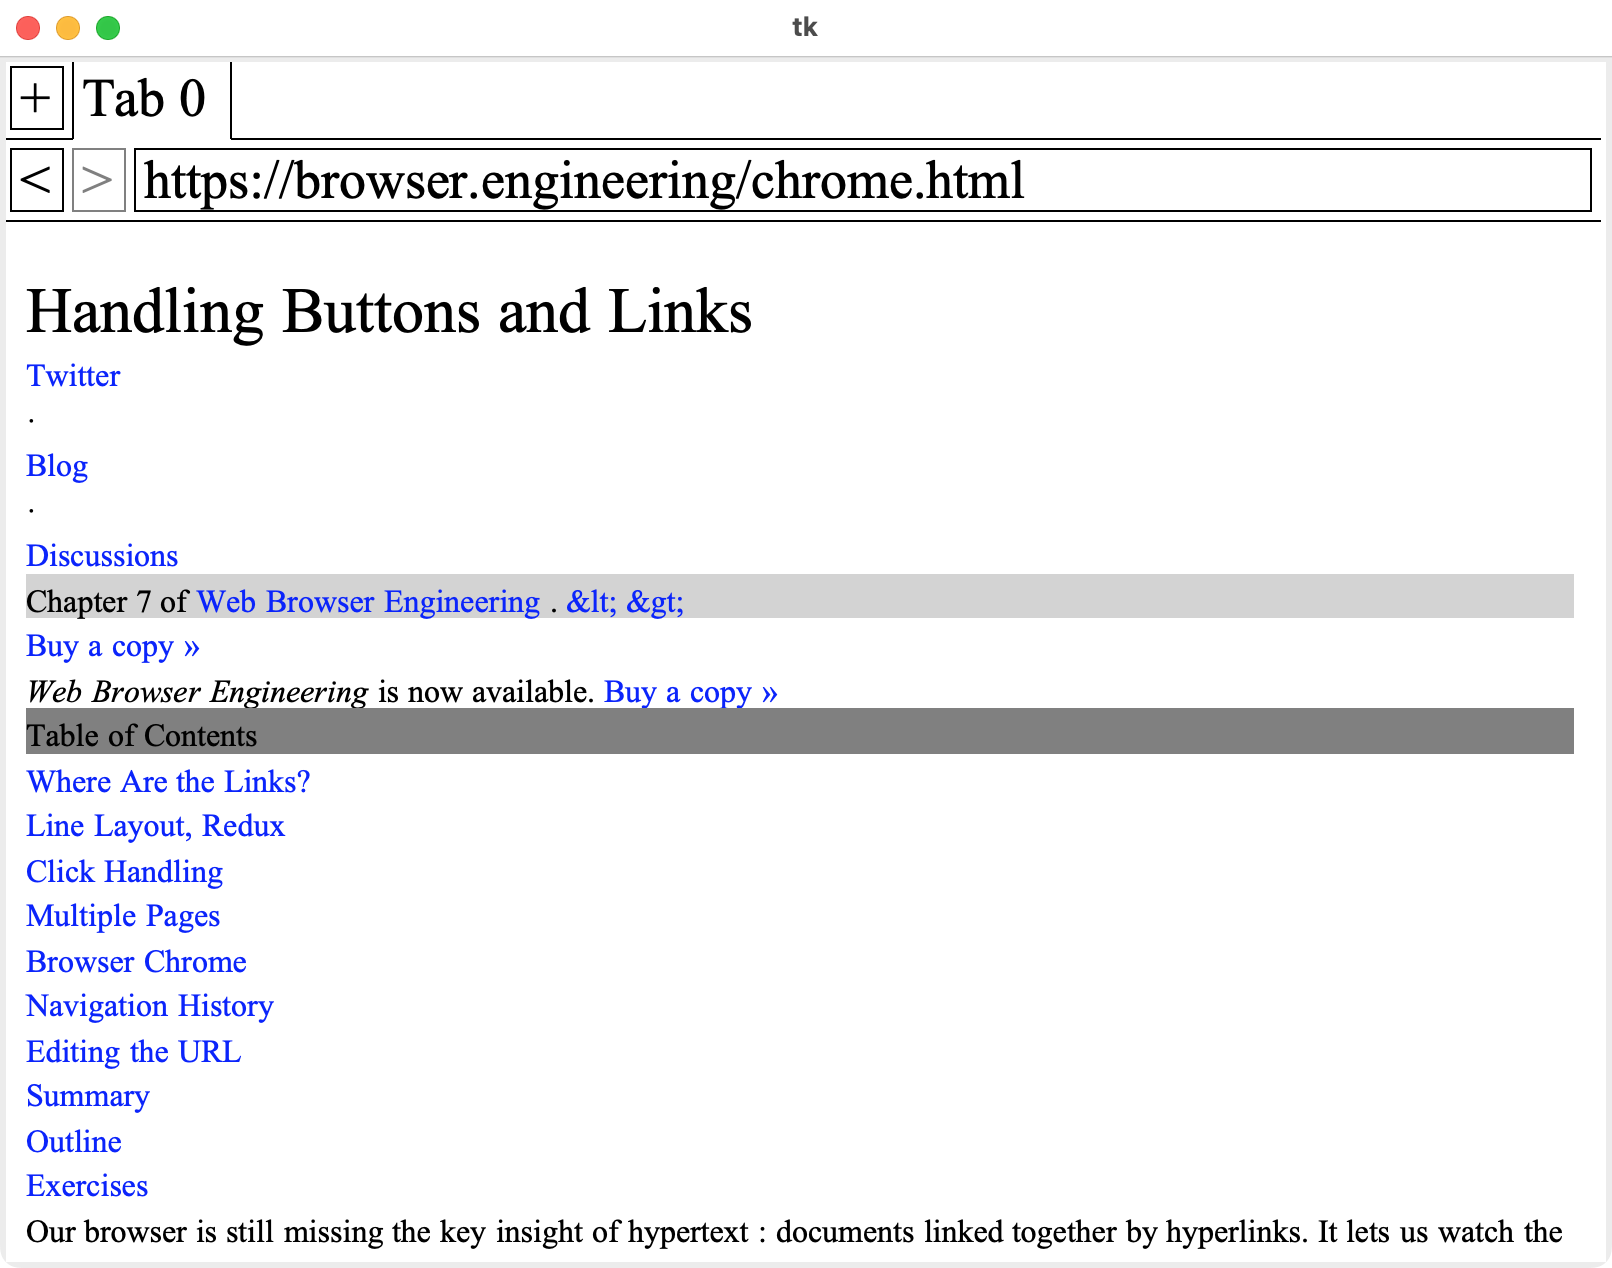

In [ ]:
# 앞으로가기 (>) 버튼 클릭 시뮬레이션
fwd_x = browser.chrome.forward_rect.left + 5
fwd_y = browser.chrome.forward_rect.top + 5
browser.handle_click(MockClick(fwd_x, fwd_y))

tab = browser.active_tab
print(f"현재 URL: {tab.url}")
print(f"방문 기록: {[str(u) for u in tab.history]}")
print(f"히스토리 포인터: {tab.history_pointer}")
print(f"뒤로가기 가능: {tab.history_pointer > 0} (색상: {'black' if tab.history_pointer > 0 else 'gray'})")
print(f"앞으로가기 가능: {tab.history_pointer < len(tab.history) - 1} (색상: {'black' if tab.history_pointer < len(tab.history) - 1 else 'gray'})")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 5: 뒤로간 후 새로운 URL로 분기 이동 (히스토리 절단 검증)

뒤로가기로 `http.html`로 돌아간 뒤, 앞으로 가지 않고 새로운 페이지(`layout.html`)로 이동합니다.
- 브라우저 세션 히스토리 사양에 따라, 기존의 미래 기록(`chrome.html`)은 히스토리에서 잘려나가고 `[http.html, layout.html]`이 됩니다.
- 따라서 앞으로가기(`>`) 버튼은 다시 **회색(gray, 비활성화)**이 됩니다.

뒤로가기 후 URL: https://browser.engineering/http.html
새 페이지 탐색 후 URL: https://browser.engineering/layout.html
최종 방문 기록: ['https://browser.engineering/http.html', 'https://browser.engineering/layout.html']
히스토리 포인터: 1
뒤로가기 가능: True (색상: black)
앞으로가기 가능: False (색상: gray)


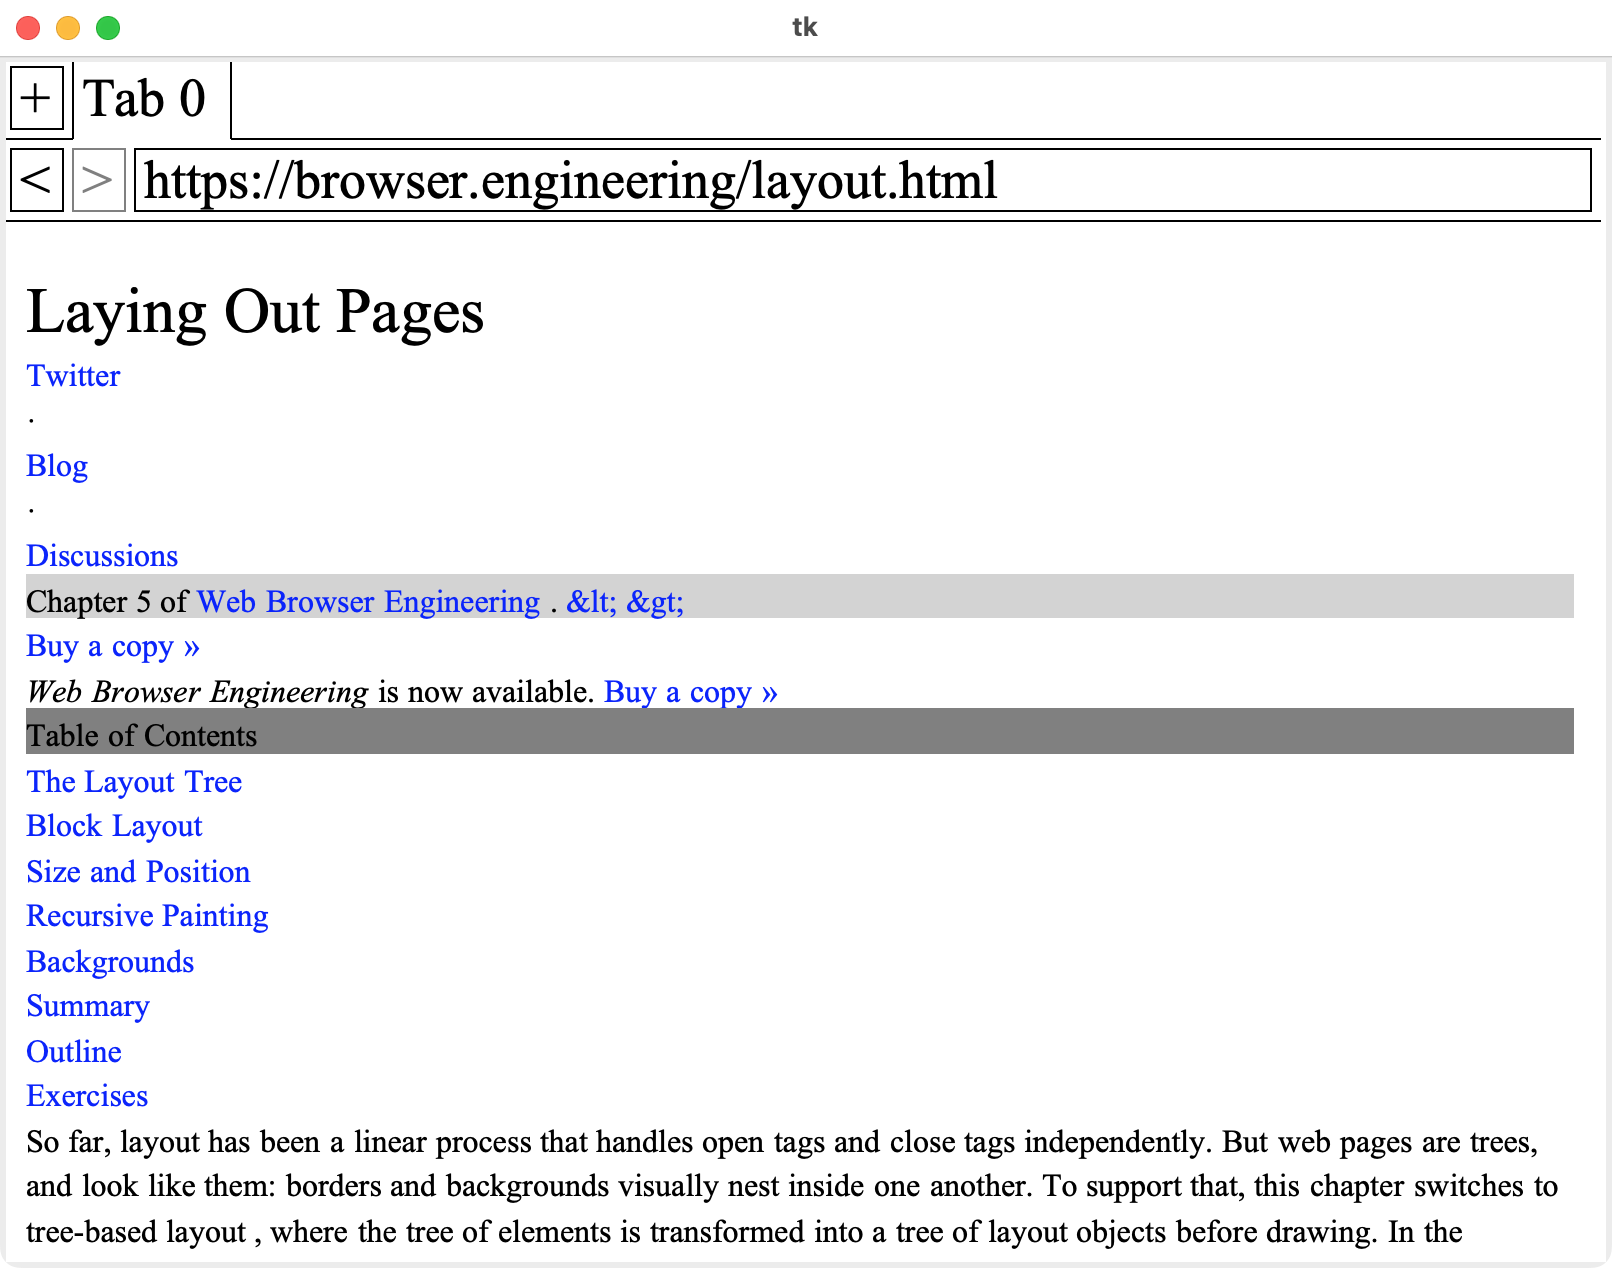

In [ ]:
# 1. 다시 뒤로가기 클릭
back_x = browser.chrome.back_rect.left + 5
back_y = browser.chrome.back_rect.top + 5
browser.handle_click(MockClick(back_x, back_y))
print(f"뒤로가기 후 URL: {browser.active_tab.url}")

# 2. 새로운 페이지 layout.html로 탐색 (기존 chrome.html 미래 기록 잘림 확인)
browser.active_tab.load(URL("https://browser.engineering/layout.html"))
browser.draw()

tab = browser.active_tab
print(f"새 페이지 탐색 후 URL: {tab.url}")
print(f"최종 방문 기록: {[str(u) for u in tab.history]}")
print(f"히스토리 포인터: {tab.history_pointer}")
print(f"뒤로가기 가능: {tab.history_pointer > 0} (색상: {'black' if tab.history_pointer > 0 else 'gray'})")
print(f"앞으로가기 가능: {tab.history_pointer < len(tab.history) - 1} (색상: {'black' if tab.history_pointer < len(tab.history) - 1 else 'gray'})")

# 마지막 테스트 셀이므로 창 파기 (destroy=True)
display_tk_window(browser.window, settle_seconds=0.4, destroy=True)


## 7.10 Exercises: 7-7 Visited links

In real browsers, links you’ve visited before are usually purple. Implement that feature. You’ll need to store the set of visited URLs, annotate the corresponding HTML elements, and check those annotations when drawing the text.

Real browsers support special pseudo-class selectors that select all visited links, which you could implement if you want.

### Step 1: 미방문 링크 확인 (초기 페이지 로드)

`VISITED_LINKS`를 초기화하고 `https://browser.engineering/chrome.html`을 로드합니다.
- 상단 내비게이션의 `Web Browser Engineering`(`index.html`) 링크는 아직 방문하지 않았으므로 `is_visited_link = False`이며 기본 링크 색상인 **파란색(blue)**으로 표시됩니다.

현재 URL: https://browser.engineering/chrome.html
방문 링크 목록 (VISITED_LINKS): ['https://browser.engineering/chrome.html']
대상 링크 텍스트: 'Web Browser Engineering' (href='index.html')
is_visited_link 마킹: False
적용된 CSS 색상(color): blue


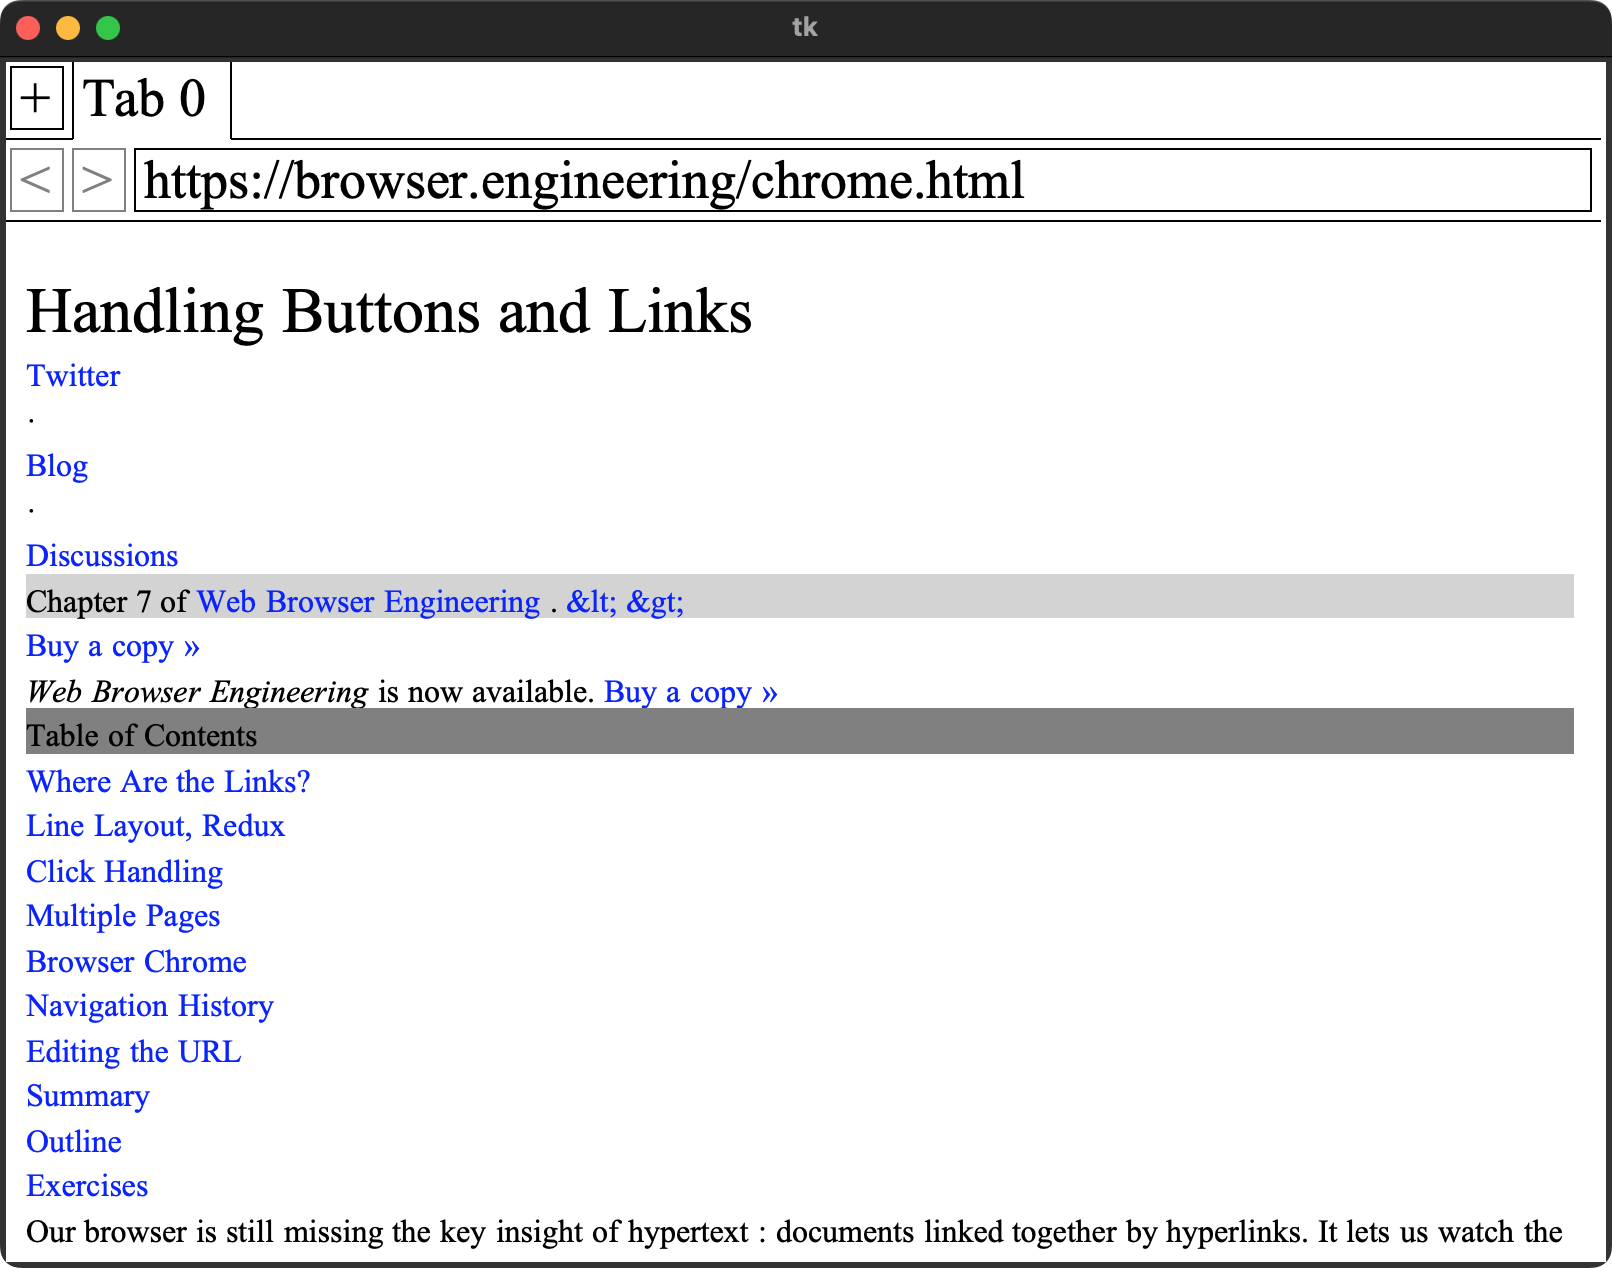

In [ ]:
import importlib
import browser.browser
import browser.css
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.css)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, VISITED_LINKS
from browser.url import URL
from browser.html import Element, tree_to_list
from browser.tk_capture import display_tk_window

# 방문 기록 초기화
VISITED_LINKS.clear()

browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))

tab = browser.active_tab
link = next(
    n for n in tree_to_list(tab.nodes, [])
    if isinstance(n, Element) and n.tag == "a" and n.attributes.get("href") == "index.html"
)
link_text = "".join(c.text for c in link.children if hasattr(c, "text"))

print(f"현재 URL: {tab.url}")
print(f"방문 링크 목록 (VISITED_LINKS): {list(VISITED_LINKS)}")
print(f"대상 링크 텍스트: '{link_text}' (href='index.html')")
print(f"is_visited_link 마킹: {getattr(link, 'is_visited_link', False)}")
print(f"적용된 CSS 색상(color): {link.style.get('color')}")

browser.draw()
display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 2: 링크 대상 페이지 방문 (`index.html`)

해당 링크의 대상 페이지인 `https://browser.engineering/index.html`로 이동합니다.
- `Tab.load()`가 실행되면서 `https://browser.engineering/index.html`이 `VISITED_LINKS` 집합에 자동으로 등록됩니다.

현재 이동된 URL: https://browser.engineering/index.html
갱신된 방문 링크 목록: ['https://browser.engineering/chrome.html', 'https://browser.engineering/index.html']


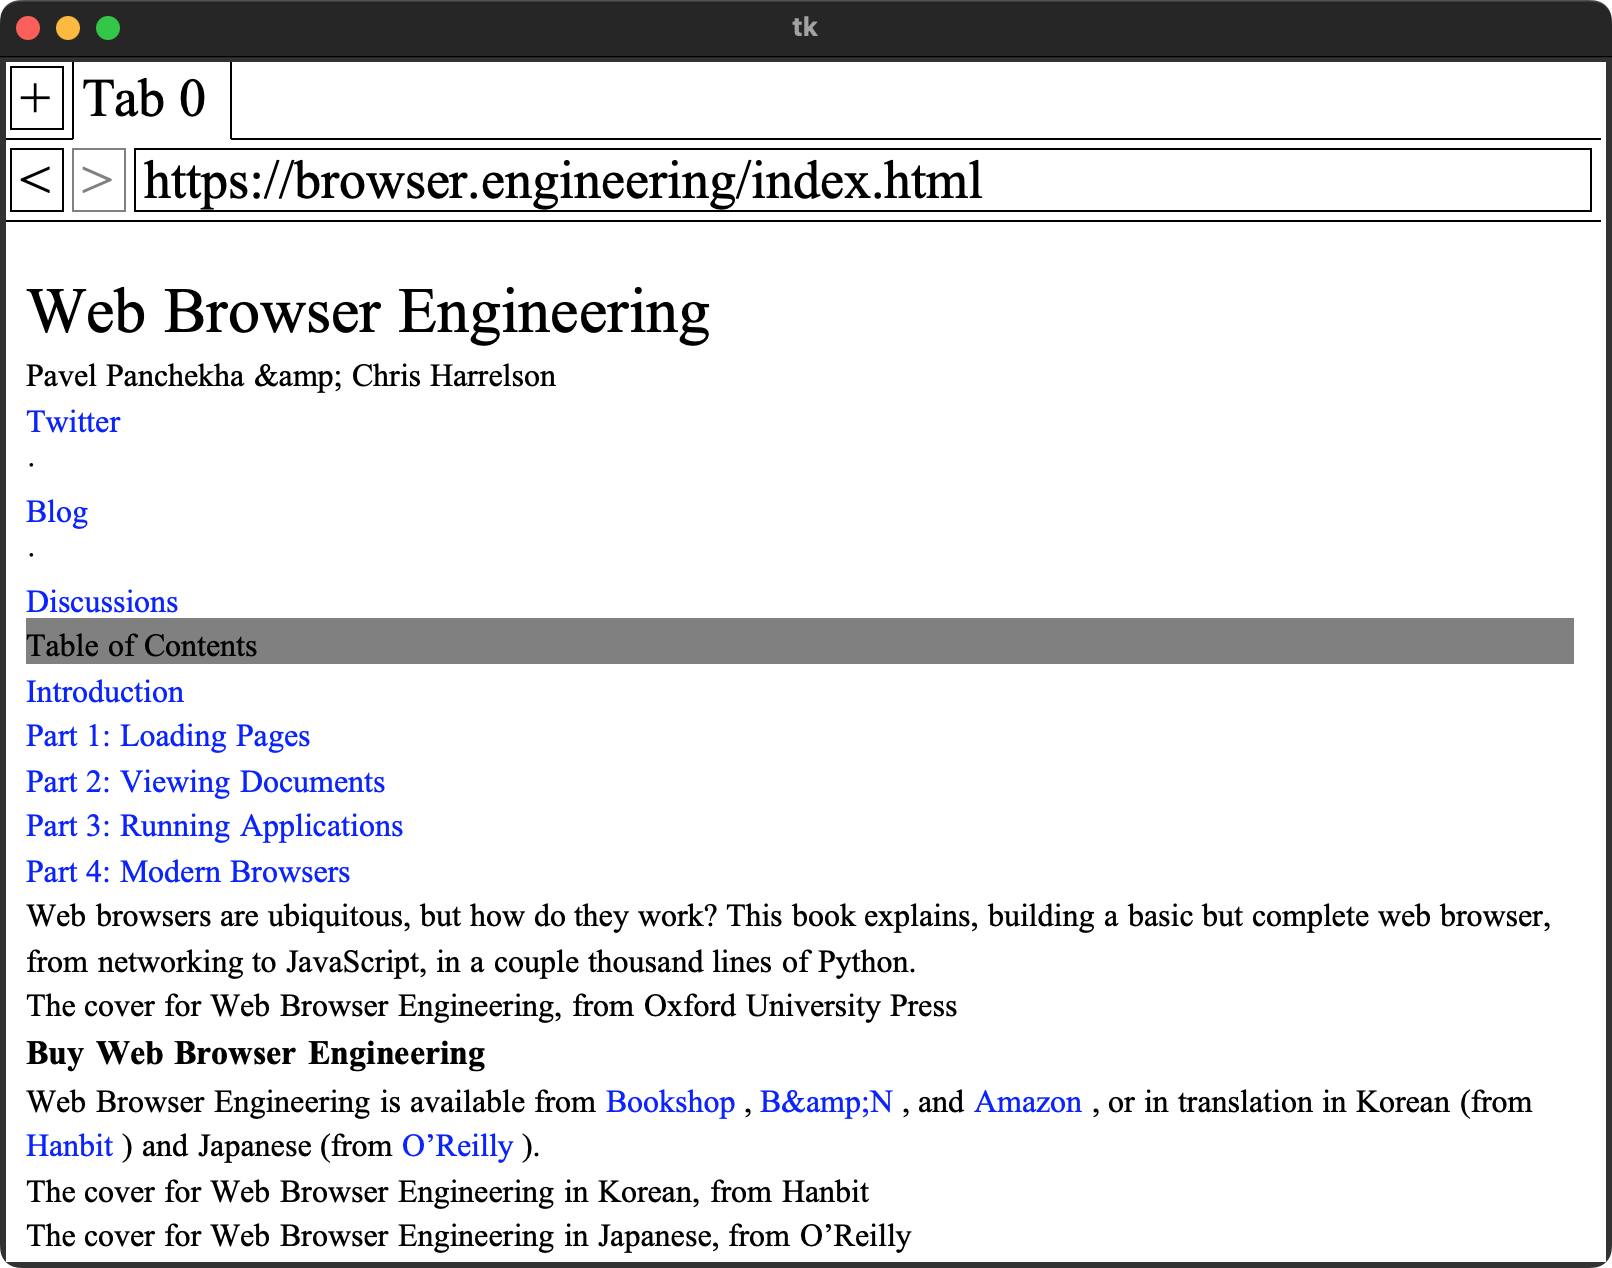

In [ ]:
# index.html로 이동
target_url = browser.active_tab.url.resolve("index.html")
browser.active_tab.load(target_url)
browser.draw()

tab = browser.active_tab
print(f"현재 이동된 URL: {tab.url}")
print(f"갱신된 방문 링크 목록: {sorted(list(VISITED_LINKS))}")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 3: 뒤로가기(`<`) 복귀 후 링크 색상 변화 확인 (Visited = purple)

뒤로가기 버튼을 클릭하여 다시 `chrome.html`로 복귀합니다.
- 이제 `index.html`이 `VISITED_LINKS`에 존재하므로, `node.is_visited_link = True`로 마킹됩니다.
- CSS 캐스케이드 과정에서 `:visited` 가상 클래스 규칙(`a:visited`)이 우선 적용되어 링크 색상이 **보라색(purple / #84a)**으로 변경됩니다! ✨

뒤로가기 후 URL: https://browser.engineering/chrome.html
방문 링크 목록 (VISITED_LINKS): ['https://browser.engineering/chrome.html', 'https://browser.engineering/index.html']
대상 링크 텍스트: 'Web Browser Engineering' (href='index.html')
is_visited_link 마킹: True
적용된 CSS 색상(color): #84a (보라색으로 변경!)


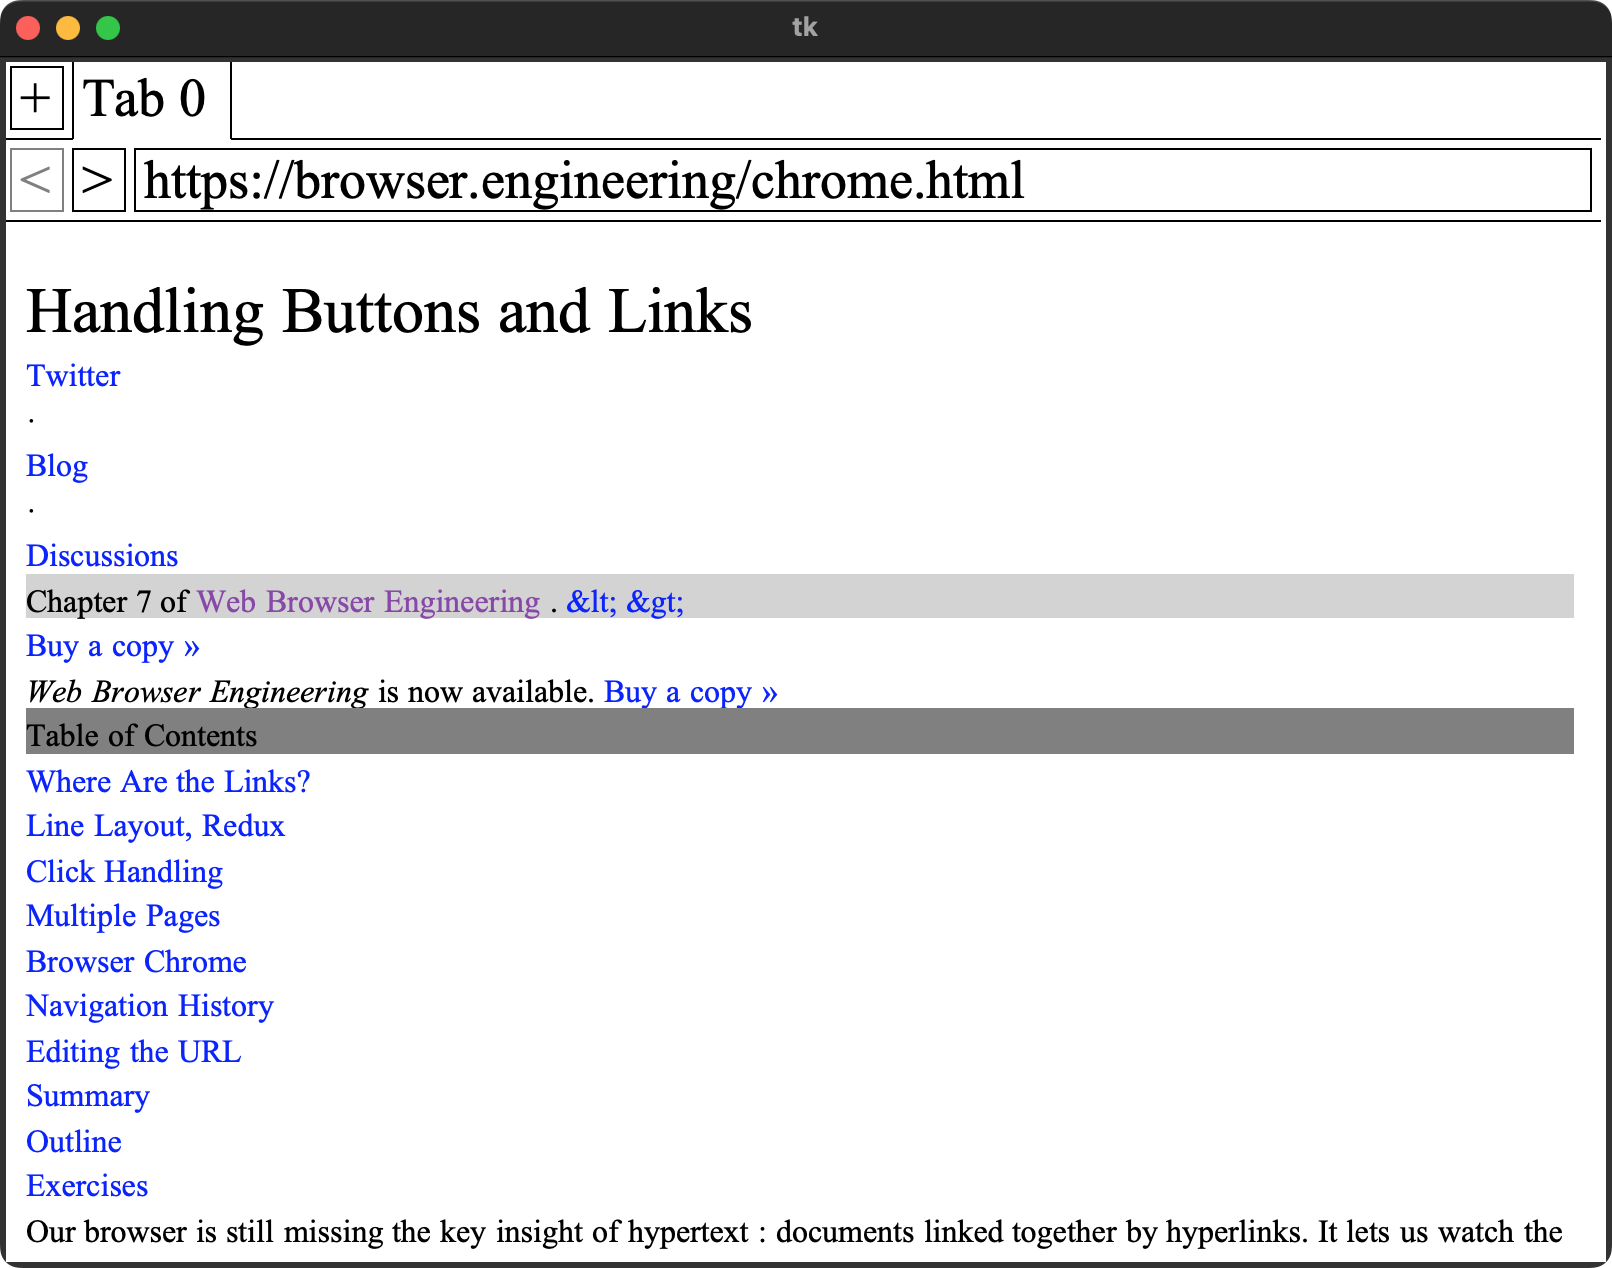

In [ ]:
# 뒤로가기 (<) 버튼 클릭 시뮬레이션
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

back_x = browser.chrome.back_rect.left + 5
back_y = browser.chrome.back_rect.top + 5
browser.handle_click(MockClick(back_x, back_y))

tab = browser.active_tab
link_after = next(
    n for n in tree_to_list(tab.nodes, [])
    if isinstance(n, Element) and n.tag == "a" and n.attributes.get("href") == "index.html"
)
link_text = "".join(c.text for c in link_after.children if hasattr(c, "text"))

print(f"뒤로가기 후 URL: {tab.url}")
print(f"방문 링크 목록 (VISITED_LINKS): {sorted(list(VISITED_LINKS))}")
print(f"대상 링크 텍스트: '{link_text}' (href='index.html')")
print(f"is_visited_link 마킹: {getattr(link_after, 'is_visited_link', False)}")
print(f"적용된 CSS 색상(color): {link_after.style.get('color')} (보라색으로 변경!)")

# 마지막 테스트 셀이므로 창 파기 (destroy=True)
display_tk_window(browser.window, settle_seconds=0.4, destroy=True)


## 7.10 Exercises: 7-9 Cursor

Make the left and right arrow keys move the text cursor around the address bar when it is focused. Pressing the backspace key should delete the character before the cursor, and typing other keys should add characters at the cursor. (Remember that the cursor can be before the first character or after the last!)

### Step 1: 주소창 포커스 및 초기 커서 위치 확인

브라우저 생성 후 주소창을 클릭합니다.
- 현재 탭의 URL이 주소창에 표시되고, 빨간색 커서 선(`|`)이 **맨 끝(`len(url)`)**에 위치합니다.

1. 주소창 클릭 -> 포커스: address bar
   현재 주소창 텍스트: 'https://browser.engineering/http.html'
   커서 인덱스: 37 (맨 끝에 위치)


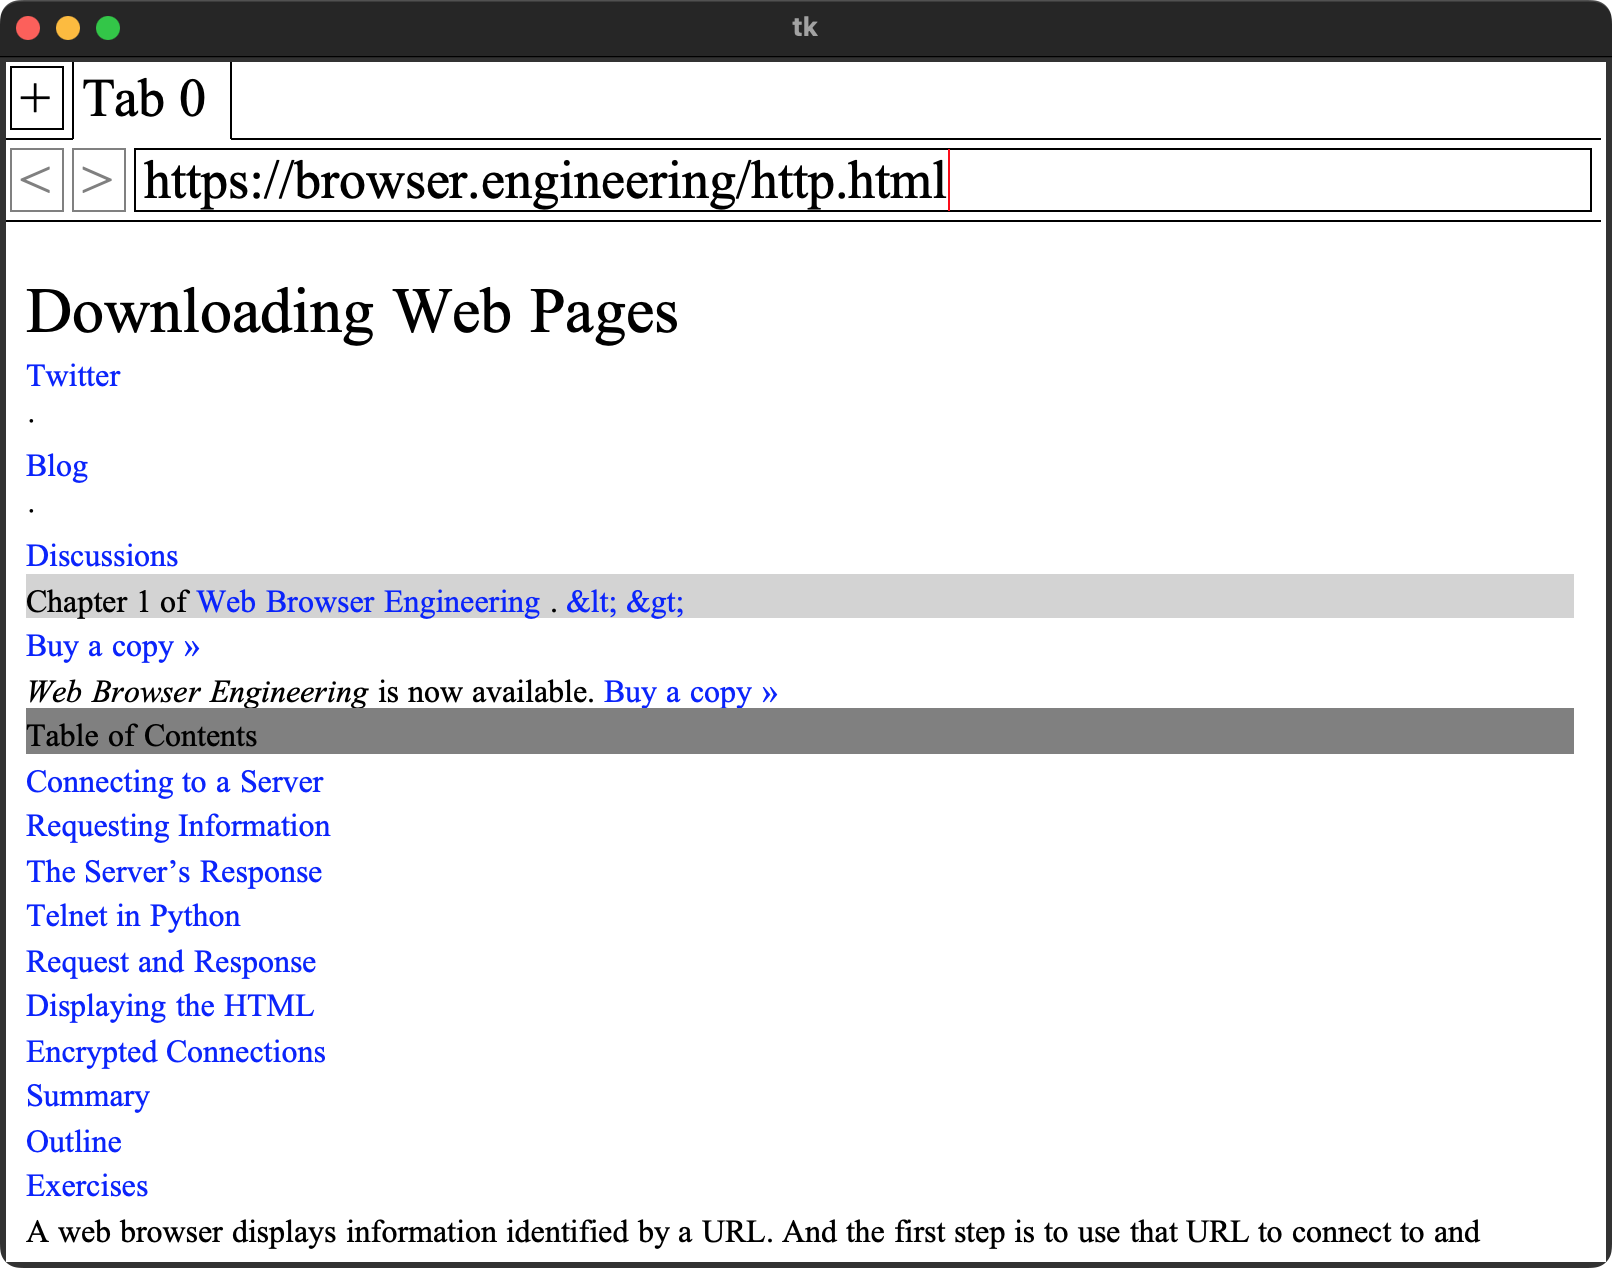

In [ ]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser
from browser.url import URL
from browser.tk_capture import display_tk_window

class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

browser = Browser()
browser.new_tab(URL("https://browser.engineering/http.html"))

# 주소창 클릭 (포커스 활성화)
addr_x = browser.chrome.address_rect.left + 5
addr_y = browser.chrome.address_rect.top + 5
browser.handle_click(MockClick(addr_x, addr_y))

print(f"주소창 포커스: {browser.chrome.focus}")
print(f"주소창 텍스트: '{browser.chrome.address_bar}'")
print(f"커서 인덱스: {browser.chrome.address_bar_cursor_index} (맨 끝 위치)")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 2: 좌측 화살표(`<Left>`) 키로 커서 이동

`<Left>` 화살표 키를 5회 입력하여 커서를 `.html` 바로 앞(`http` 뒤)으로 이동합니다.
- 빨간색 커서 선이 문자열 중간으로 정확히 이동한 것을 확인할 수 있습니다.

2. 왼쪽 화살표(<Left>) 5회 입력...
   현재 커서 인덱스: 32
   커서 앞 텍스트: 'https://browser.engineering/http'
   커서 뒤 텍스트: '.html'


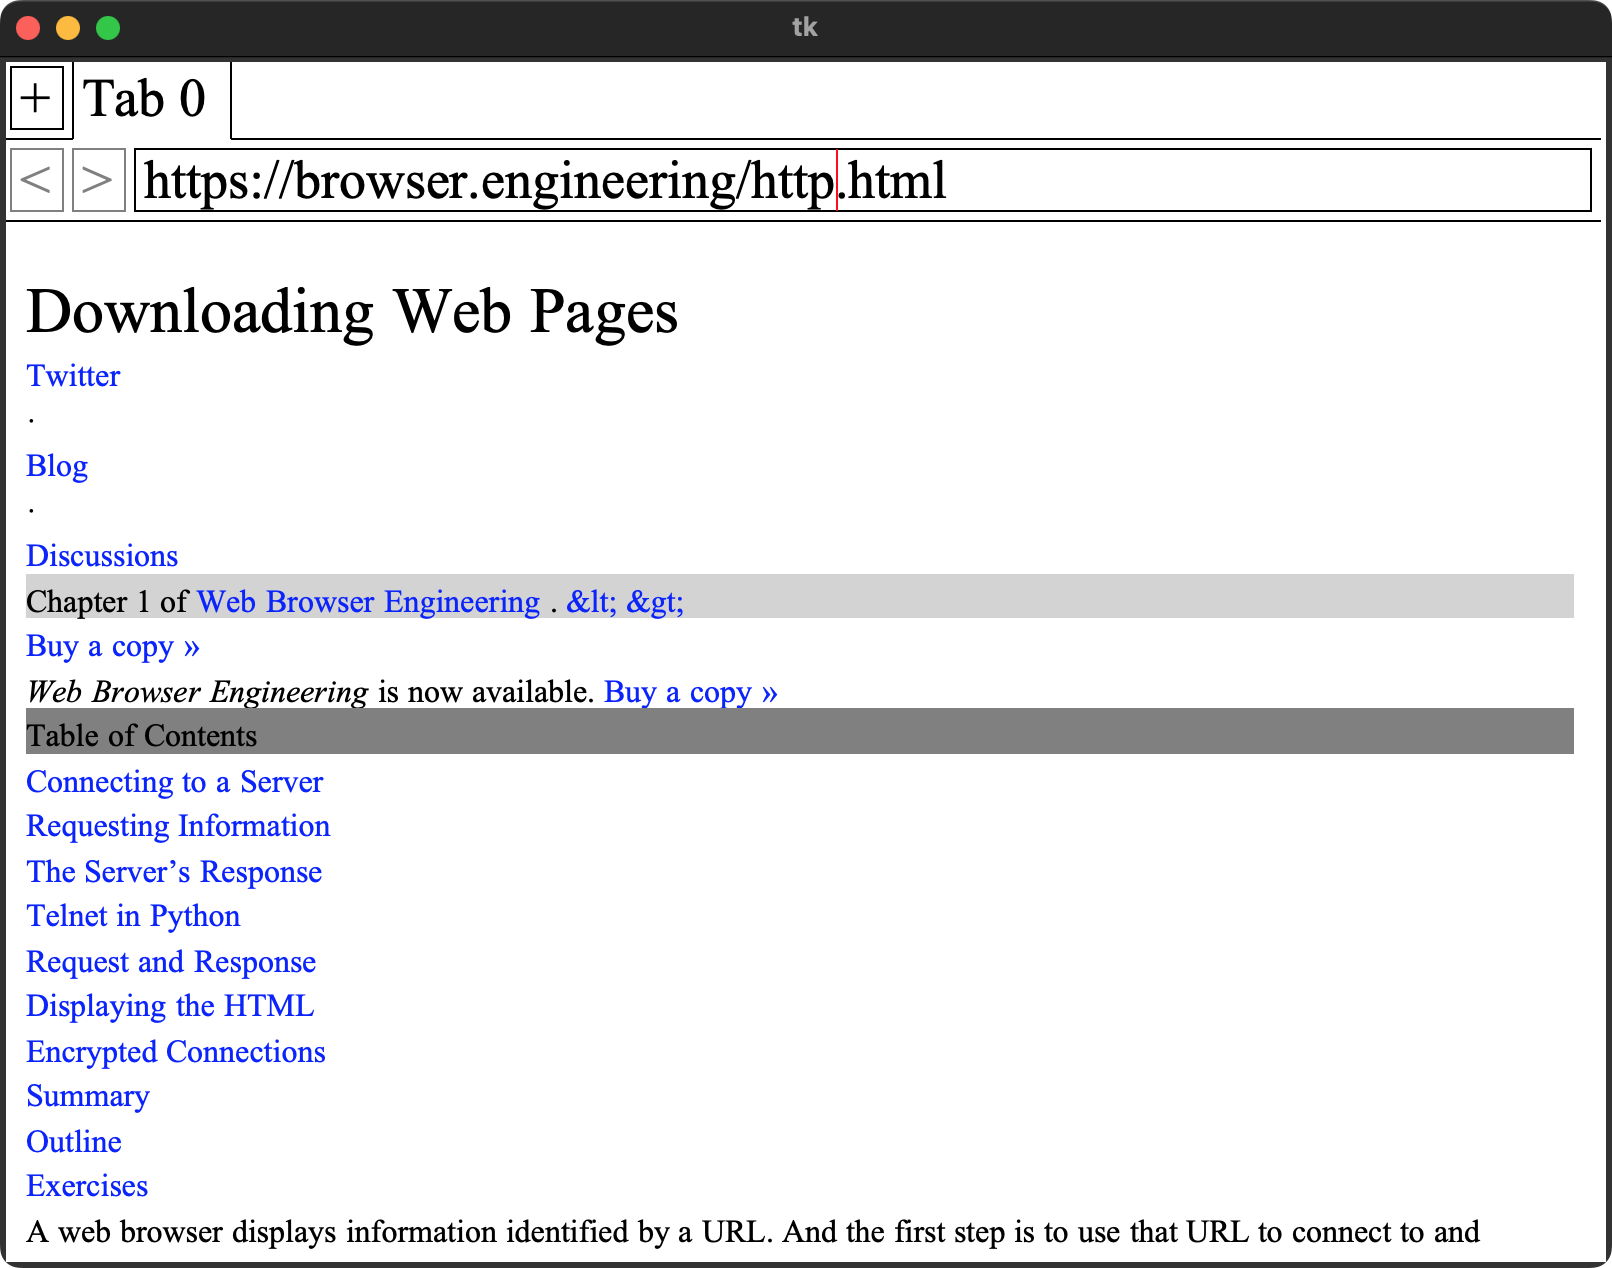

In [ ]:
# 왼쪽 화살표(<Left>) 5회 입력으로 커서 이동
for _ in range(5):
    browser.handle_left(None)

c_idx = browser.chrome.address_bar_cursor_index
print(f"현재 커서 인덱스: {c_idx}")
print(f"커서 앞 텍스트: '{browser.chrome.address_bar[:c_idx]}'")
print(f"커서 뒤 텍스트: '{browser.chrome.address_bar[c_idx:]}'")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 3: 커서 위치에 글자 삽입 (`keypress`)

커서가 위치한 중간 지점에 `_test` 글자를 타이핑합니다.
- 글자가 커서 위치에 정확히 삽입되고, 뒤에 있던 `.html`은 밀려나며 커서도 함께 이동합니다.

3. 커서 위치에 '_test' 입력 시뮬레이션...
   수정된 주소창 텍스트: 'https://browser.engineering/http_test.html'
   현재 커서 인덱스: 37


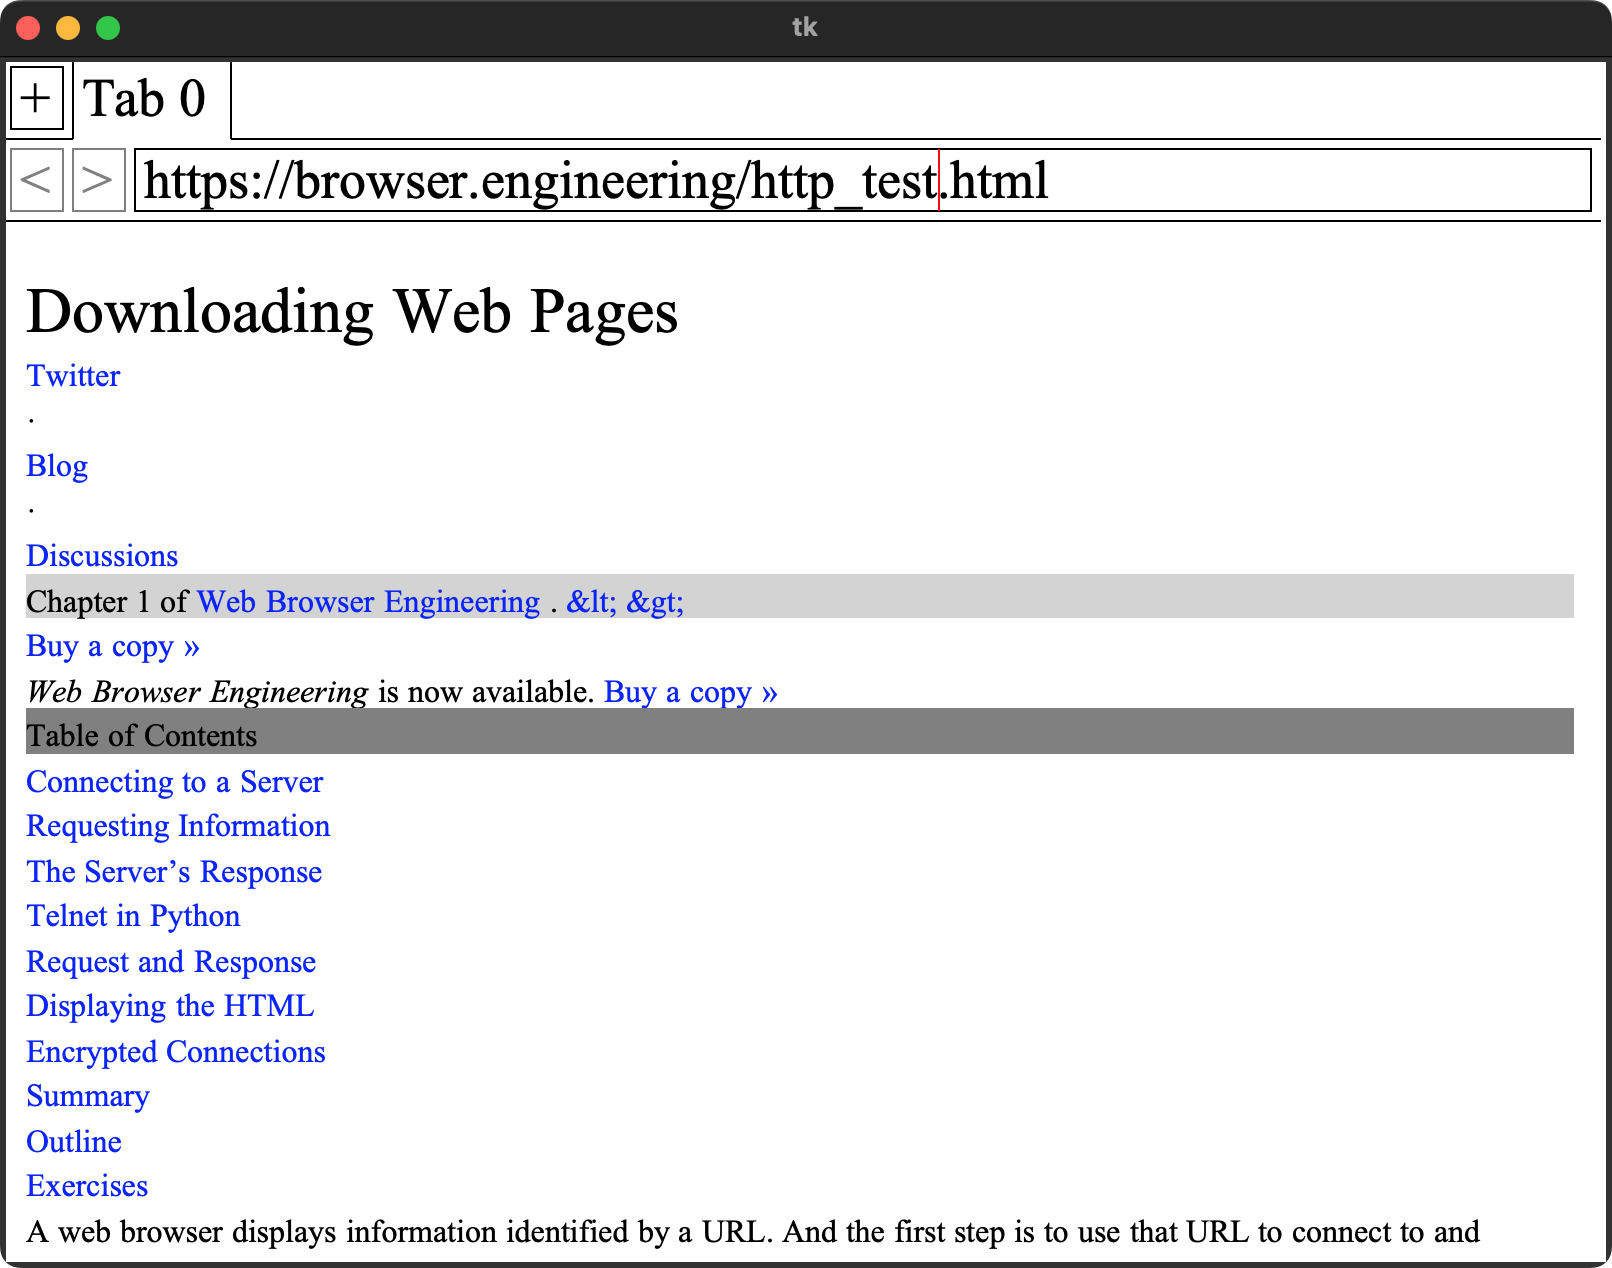

In [ ]:
class MockKey:
    def __init__(self, char):
        self.char = char

# 커서 위치에 '_test' 타이핑
for ch in "_test":
    browser.handle_key(MockKey(ch))

print(f"수정된 주소창 텍스트: '{browser.chrome.address_bar}'")
print(f"현재 커서 인덱스: {browser.chrome.address_bar_cursor_index}")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 4: 백스페이스(`<BackSpace>`)로 커서 앞 글자만 삭제

백스페이스 키를 5회 입력합니다.
- 커서 앞의 `_test`만 깔끔하게 삭제되고, 커서 뒤의 `.html`은 안전하게 보존되어 원래 URL로 복구됩니다.

4. 백스페이스(<BackSpace>) 5회 입력 (커서 앞 '_test' 삭제)...
   복구된 주소창 텍스트: 'https://browser.engineering/http.html'
   현재 커서 인덱스: 32
   -> 커서 뒤의 '.html'은 안전하게 유지됨!


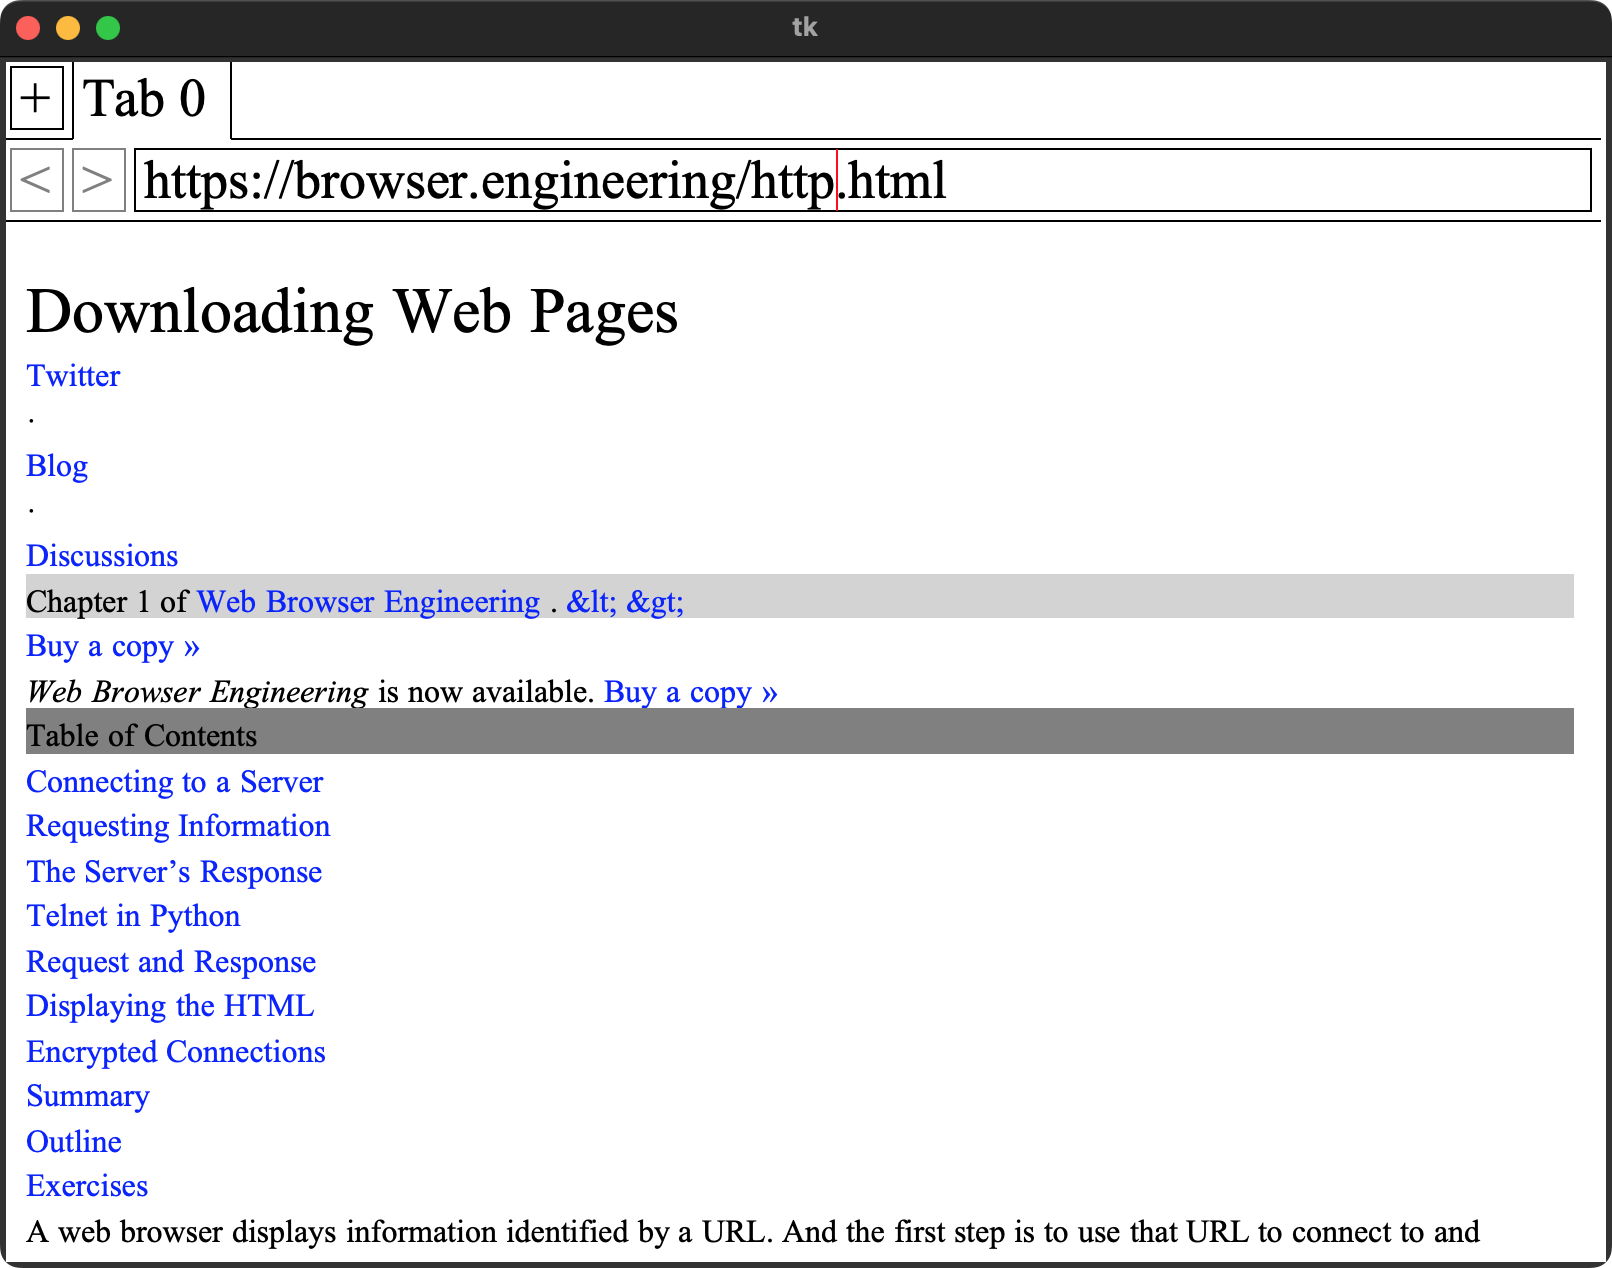

In [ ]:
# 백스페이스(<BackSpace>) 5회 입력
for _ in range(5):
    browser.handle_backspace(None)

print(f"복구된 주소창 텍스트: '{browser.chrome.address_bar}'")
print(f"현재 커서 인덱스: {browser.chrome.address_bar_cursor_index}")

display_tk_window(browser.window, settle_seconds=0.4, destroy=False)


### Step 5: URL 수정 후 엔터(`<Return>`) 키로 이동

커서를 이동하여 `http`를 `chrome`으로 수정한 후 엔터 키를 누릅니다.
- 수정된 `https://browser.engineering/chrome.html` 페이지로 이동하고 주소창 포커스가 해제됩니다.

5. URL을 'chrome.html'로 수정 후 Enter 입력...
   이동 완료! 현재 탭 URL: https://browser.engineering/chrome.html
   주소창 포커스 상태: None


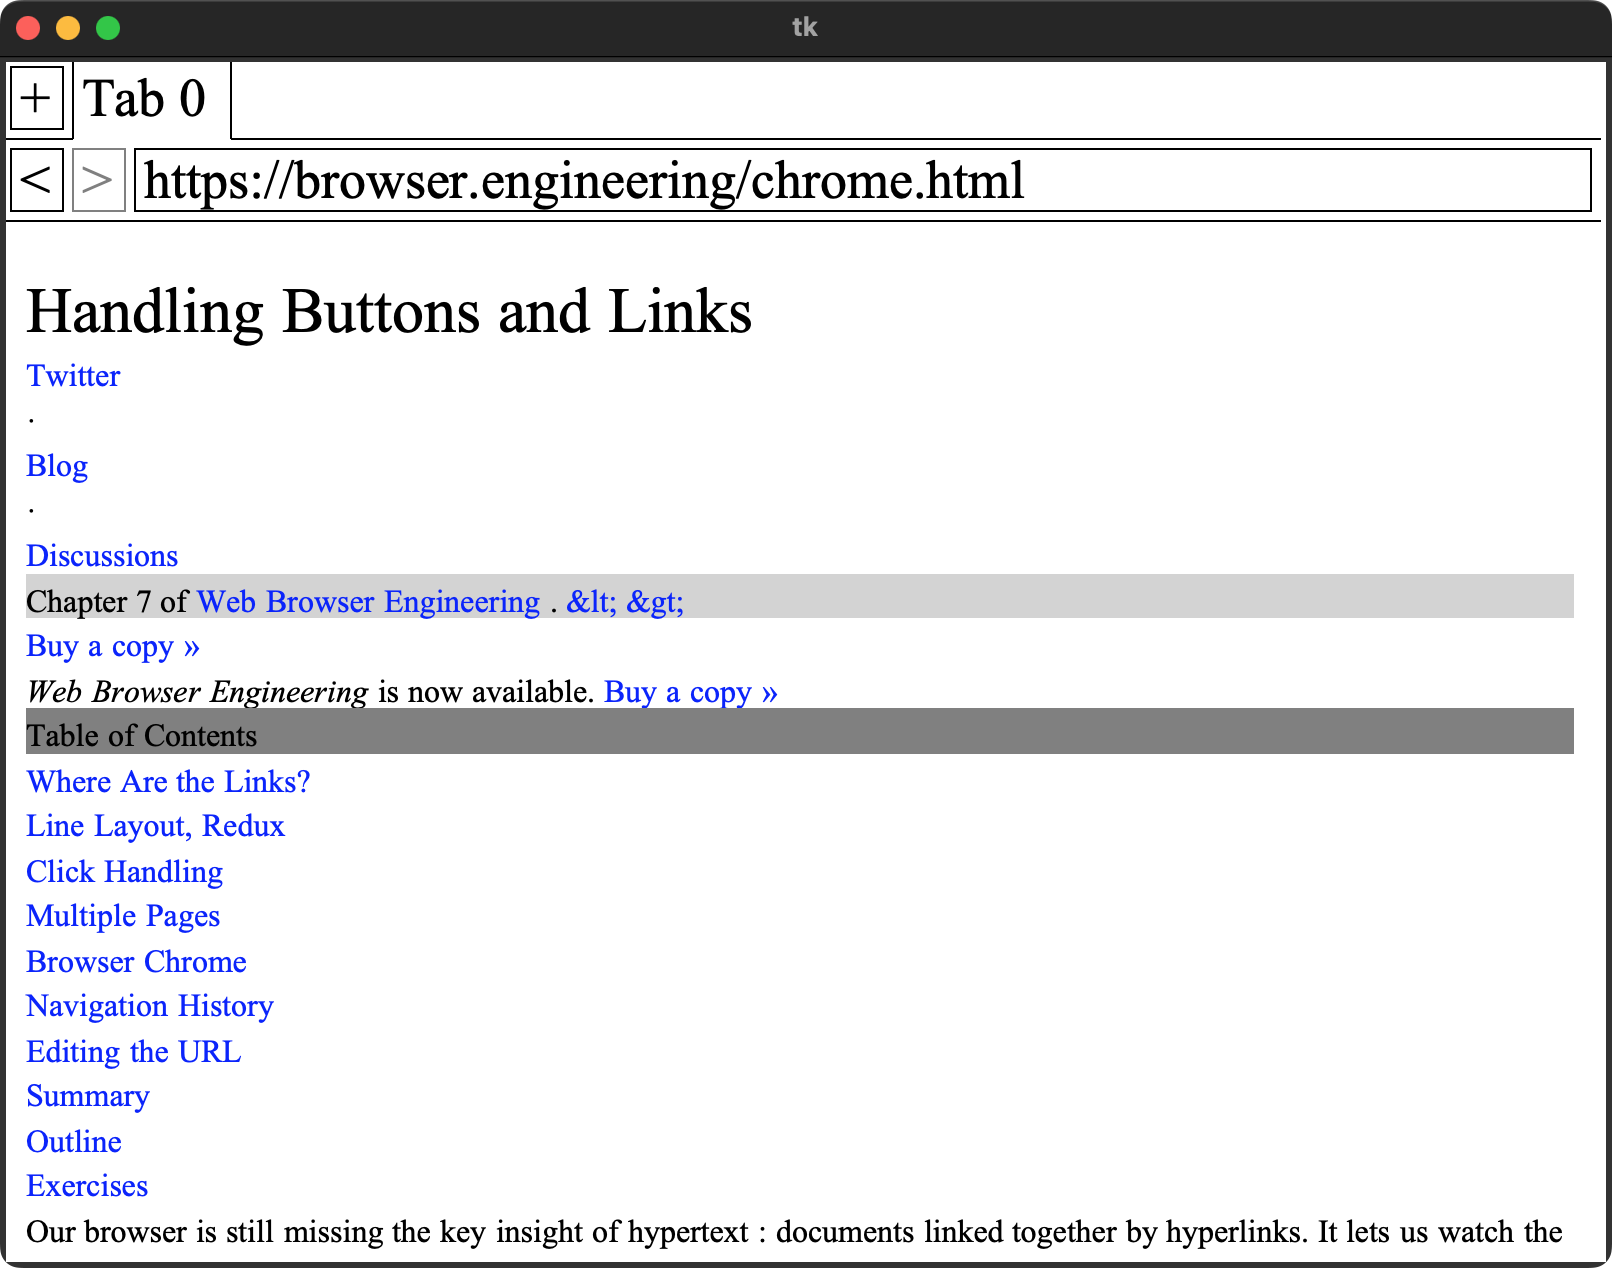

In [ ]:
# 1. 커서 앞의 'http' 4글자 백스페이스 삭제
for _ in range(4):
    browser.handle_backspace(None)
# 2. 'chrome' 타이핑
for ch in "chrome":
    browser.handle_key(MockKey(ch))

# 3. Enter 키로 페이지 이동
browser.handle_enter(None)

print(f"이동 완료! 현재 탭 URL: {browser.active_tab.url}")
print(f"주소창 포커스: {browser.chrome.focus}")

# 마지막 테스트 셀이므로 창 파기 (destroy=True)
display_tk_window(browser.window, settle_seconds=0.4, destroy=True)
